# 01 LSTM Models With True Sequences Using 99/1 Train/Test Split
This and the previous noetbook use nearly the exact same models as the "Improved Models" notebooks that we tested previously. However, we have corrected our normalization process in these notebooks. Instead of normalizing all price features to the Open of the current day (and the volume features to the Previous Day Volume), we scaled everything to the maximum for all the dates for each ticker. A more in-depth explanation is provided below when we create this sequence data.

## Imports

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
from datetime import date
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.plotting import heatmap

import tulipy as ti

import sklearn
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.decomposition import KernelPCA
from sklearn.decomposition import IncrementalPCA

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras import initializers
import keras_tuner as kt
from keras_tuner import HyperParameters

import os
import sys
import warnings

# Data Loading and Initial Feature Engineering for LSTM Model

## Getting S&P500 Table Data

### Old method (risky since S&P500 Wikipedia might change randomly)

As of March 11, 2025, the last time a stock was added or removed from the S&P500 Wikipedia list was in December 2024. Therefore, for the extent of this project thus far, this shouldn't have affected us at all. However, we should keep a consistent csv of the stocks so we can have consistent GICS sectors (in case they change for some reason).

In [27]:
# Getting the S&P500 tables
sp500_tables = pd.read_html('https://en.wikipedia.org/wiki/List_of_S%26P_500_companies')

In [26]:
# Getting the S&P500 list into a csv (only need to do once)
# df_sp500 = sp500_tables[0]
# df_sp500.to_csv('SP500_Tickers_March_2025.csv')

### Get S&P500 current list of stocks and their sectors using downloaded csv file

In [2]:
sp500_tables = pd.read_csv('SP500_Tickers_March_2025.csv', index_col='Unnamed: 0')
sp500_tables.head()

,Symbol,Security,GICS Sector,GICS Sub-Industry,Headquarters Location,Date added,CIK,Founded
0,MMM,3M,Industrials,Industrial Conglomerates,"Saint Paul, Minnesota",1957-03-04,66740,1902
1,AOS,A. O. Smith,Industrials,Building Products,"Milwaukee, Wisconsin",2017-07-26,91142,1916
2,ABT,Abbott Laboratories,Health Care,Health Care Equipment,"North Chicago, Illinois",1957-03-04,1800,1888
3,ABBV,AbbVie,Health Care,Biotechnology,"North Chicago, Illinois",2012-12-31,1551152,2013 (1888)
4,ACN,Accenture,Information Technology,IT Consulting & Other Services,"Dublin, Ireland",2011-07-06,1467373,1989


## Loading in Data

In [3]:
# Loading in stock data
data = pd.read_csv("SP500_4y_day_data.csv", index_col='Date', parse_dates=True)

In [4]:
# Converting Date_col to datetime format
data['Date_col'] = pd.to_datetime(data['Date_col'])

In [5]:
data

,Date_col,Ticker,Open,High,Low,Close,Volume,rank
Date,,,,,,,,
2021-01-04,2021-01-04,A,115.875028,116.995388,114.092184,115.582756,2030700.0,1.0
2021-01-05,2021-01-05,A,115.426870,117.219451,115.027432,116.527748,2344000.0,2.0
2021-01-06,2021-01-06,A,115.631454,120.687707,115.163820,119.723221,2428500.0,3.0
2021-01-07,2021-01-07,A,121.126122,124.194950,120.911790,122.908966,1775900.0,4.0
2021-01-08,2021-01-08,A,123.230471,124.350838,122.606963,123.785782,1577200.0,5.0
...,...,...,...,...,...,...,...,...
2024-12-24,2024-12-24,ZTS,163.206597,164.542554,162.249499,164.203583,1023600.0,1001.0
2024-12-26,2024-12-26,ZTS,163.226540,165.290293,162.528653,165.021118,2167200.0,1002.0
2024-12-27,2024-12-27,ZTS,164.452833,166.028073,163.027150,164.103897,1800100.0,1003.0


## Feature Engineering
Outcome variables - Close price minus the Open price and variations of that

In [6]:
# Getting difference between close price and open price (outcome variables)
data["Close_Open_Diff"] = data["Close"] - data["Open"]
data["Close_Open_Diff_Perc"] = (data["Close"] - data["Open"]) / data["Open"] * 100

# Getting binary classification for whether a stock ended positive (1) or negative/zero (0)
data["Close_Open_Diff_Binary"] = data["Close_Open_Diff"] > 0

# Getting ternary classification for whether a stock ended positive (2), negative (0), or not much change (1)
close_open_conditions = [
    data['Close_Open_Diff_Perc'] > 0.5,       # Close price was at least 0.5% higher than Open price
    (data['Close_Open_Diff_Perc'] >= -0.5) &  # Close price was between -0.5% and 0.5% of Open price
        (data['Close_Open_Diff_Perc'] <= 0.5),
    data['Close_Open_Diff_Perc'] < -0.5       # Close price was at least 0.5% lower than Open price
]
close_open_choices = [2, 1, 0]  # Defining choices corresponding to conditions
data['Close_Open_Diff_Ternary'] = np.select(close_open_conditions, close_open_choices)  # Applying conditions

data

,Date_col,Ticker,Open,High,Low,Close,Volume,rank,Close_Open_Diff,Close_Open_Diff_Perc,Close_Open_Diff_Binary,Close_Open_Diff_Ternary
Date,,,,,,,,,,,,
2021-01-04,2021-01-04,A,115.875028,116.995388,114.092184,115.582756,2030700.0,1.0,-0.292272,-0.252231,False,1
2021-01-05,2021-01-05,A,115.426870,117.219451,115.027432,116.527748,2344000.0,2.0,1.100878,0.953745,True,2
2021-01-06,2021-01-06,A,115.631454,120.687707,115.163820,119.723221,2428500.0,3.0,4.091766,3.538627,True,2
2021-01-07,2021-01-07,A,121.126122,124.194950,120.911790,122.908966,1775900.0,4.0,1.782844,1.471891,True,2
2021-01-08,2021-01-08,A,123.230471,124.350838,122.606963,123.785782,1577200.0,5.0,0.555311,0.450628,True,1
...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-24,2024-12-24,ZTS,163.206597,164.542554,162.249499,164.203583,1023600.0,1001.0,0.996986,0.610874,True,2
2024-12-26,2024-12-26,ZTS,163.226540,165.290293,162.528653,165.021118,2167200.0,1002.0,1.794578,1.099440,True,2
2024-12-27,2024-12-27,ZTS,164.452833,166.028073,163.027150,164.103897,1800100.0,1003.0,-0.348936,-0.212180,False,1


Getting previous day metrics (since we don't know current day's metrics except open) and growth rates

In [7]:
# Getting the first actual trading day
first_trading_date = str(data.Date_col.idxmin().date())

# Getting growth rates and previous day OHLCV metrics
for x in data.columns[2:-6]:
  data[f'Growth Rate_{x}'] = (data[x] - data[x].shift(1))/data[x].shift(1) * 100
data["PDO"] = data["Open"].shift(1)
data["PDH"] = data["High"].shift(1)
data["PDL"] = data["Low"].shift(1)
data["PDC"] = data["Close"].shift(1)
data["PDV"] = data["Volume"].shift(1)

# For row in data, if date is first trading date, set above column values to null. Note: date is the index:
data.loc[first_trading_date, ['PDO', 'PDH', 'PDL', 'PDC', 'PDV', 'Growth Rate_Open', 'Growth Rate_High', 'Growth Rate_Low',
    'Growth Rate_Close']] = np.nan

data.head()

,Date_col,Ticker,Open,High,Low,Close,Volume,rank,Close_Open_Diff,Close_Open_Diff_Perc,...,Close_Open_Diff_Ternary,Growth Rate_Open,Growth Rate_High,Growth Rate_Low,Growth Rate_Close,PDO,PDH,PDL,PDC,PDV
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-04,2021-01-04,A,115.875028,116.995388,114.092184,115.582756,2030700.0,1.0,-0.292272,-0.252231,...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-05,2021-01-05,A,115.426870,117.219451,115.027432,116.527748,2344000.0,2.0,1.100878,0.953745,...,2,-0.386760,0.191515,0.819730,0.817589,115.875028,116.995388,114.092184,115.582756,2030700.0
2021-01-06,2021-01-06,A,115.631454,120.687707,115.163820,119.723221,2428500.0,3.0,4.091766,3.538627,...,2,0.177242,2.958772,0.118571,2.742242,115.426870,117.219451,115.027432,116.527748,2344000.0
2021-01-07,2021-01-07,A,121.126122,124.194950,120.911790,122.908966,1775900.0,4.0,1.782844,1.471891,...,2,4.751879,2.906048,4.991124,2.660925,115.631454,120.687707,115.163820,119.723221,2428500.0
2021-01-08,2021-01-08,A,123.230471,124.350838,122.606963,123.785782,1577200.0,5.0,0.555311,0.450628,...,1,1.737320,0.125518,1.401992,0.713386,121.126122,124.194950,120.911790,122.908966,1775900.0


Getting gap (i.e., change from some previous day metric) features and volume features

In [8]:
# Getting the opening gap features from PDC
data["Gap_from_PDC"] = (data["Open"] - data["PDC"]) / data["PDC"]
gap_from_PDC_threshold = 0.02  # 2%
data["Gap_Binary_Threshold"] = abs(data["Gap_from_PDC"]) > gap_from_PDC_threshold

# Getting daily range gap up features
data["Daily_Range_Gap_Up"] = (data["Open"] - data["PDH"]) / data["PDH"]
data["Daily_Range_Gap_Up"] = data["Daily_Range_Gap_Up"].clip(lower = 0)
data["DR_Gap_Up_Binary"] = data["Daily_Range_Gap_Up"] > 0

# Getting daily range gap down features
data["Daily_Range_Gap_Down"] = (data["Open"] - data["PDL"]) / data["PDL"]
data["Daily_Range_Gap_Down"] = data["Daily_Range_Gap_Down"].clip(upper = 0)
data["DR_Gap_Down_Binary"] = data["Daily_Range_Gap_Down"] < 0

# Getting 14-day average volume and previous volume features
avg_vol_window = 14
data["Avg_Volume_14D"] = data["Volume"].rolling(window=avg_vol_window).mean()
data["Avg_Vol_Prev_14D"] = data["PDV"].rolling(window=avg_vol_window).mean()

# Comparing current volume to average volume over the past XX days
data["Vol_Change"] = (data["Volume"] - data["Avg_Vol_Prev_14D"]) / data["Avg_Vol_Prev_14D"]

# Setting the first 14-day volume averages and previous averages of every ticker to np.nan
data.loc[data["rank"] < 15, ["Avg_Volume_14D", "Avg_Vol_Prev_14D", "Vol_Change"]] = np.nan

data[10:20]

,Date_col,Ticker,Open,High,Low,Close,Volume,rank,Close_Open_Diff,Close_Open_Diff_Perc,...,PDV,Gap_from_PDC,Gap_Binary_Threshold,Daily_Range_Gap_Up,DR_Gap_Up_Binary,Daily_Range_Gap_Down,DR_Gap_Down_Binary,Avg_Volume_14D,Avg_Vol_Prev_14D,Vol_Change
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-19,2021-01-19,A,124.097539,124.506722,123.035631,124.068314,1677200.0,11.0,-0.029226,-0.023551,...,2115400.0,0.009270,False,0.002045,True,0.000000,False,NaN,NaN,NaN
2021-01-20,2021-01-20,A,124.419037,125.597856,124.078058,124.808731,1843000.0,12.0,0.389694,0.313211,...,1677200.0,0.002827,False,0.000000,False,0.000000,False,NaN,NaN,NaN
2021-01-21,2021-01-21,A,124.477480,125.461455,123.162270,123.727325,1612100.0,13.0,-0.750155,-0.602643,...,1843000.0,-0.002654,False,0.000000,False,0.000000,False,NaN,NaN,NaN
2021-01-22,2021-01-22,A,123.805281,124.506729,123.045382,123.074608,1438700.0,14.0,-0.730673,-0.590179,...,1612100.0,0.000630,False,0.000000,False,0.000000,False,NaN,NaN,NaN
2021-01-25,2021-01-25,A,123.425324,124.194968,121.223560,122.246506,1365400.0,15.0,-1.178819,-0.955086,...,1438700.0,0.002850,False,0.000000,False,0.000000,False,1.728993e+06,1.776514e+06,-0.231416
2021-01-26,2021-01-26,A,122.265994,122.704395,120.678000,120.726707,1476600.0,16.0,-1.539287,-1.258966,...,1365400.0,0.000159,False,0.000000,False,0.000000,False,1.667036e+06,1.728993e+06,-0.145977
2021-01-27,2021-01-27,A,118.934108,119.830399,115.066411,115.738632,1923500.0,17.0,-3.195476,-2.686762,...,1476600.0,-0.014848,False,0.000000,False,-0.014451,True,1.630964e+06,1.667036e+06,0.153845
2021-01-28,2021-01-28,A,115.933484,119.508910,115.719152,118.427513,1677900.0,18.0,2.494029,2.151258,...,1923500.0,0.001684,False,0.000000,False,0.000000,False,1.623964e+06,1.630964e+06,0.028778
2021-01-29,2021-01-29,A,118.086527,118.554161,116.206261,117.073326,1822000.0,19.0,-1.013201,-0.858016,...,1677900.0,-0.002879,False,0.000000,False,0.000000,False,1.641450e+06,1.623964e+06,0.121946


Getting technical and momentum indicators

In [9]:
# SMA and EMA including this period
data["SMA_14"] = data["Close"].rolling(window=14).mean()
data["SMA_50"] = data["Close"].rolling(window=50).mean()
data["SMA_200"] = data["Close"].rolling(window=200).mean()
data["EMA_9"] = data["Close"].ewm(span=9, adjust=False).mean()
data["EMA_20"] = data["Close"].ewm(span=20, adjust=False).mean()

# SMA and EMA for the past XXX periods
data["SMA_prev_14"] = data["PDC"].rolling(window=14).mean()
data["SMA_prev_50"] = data["PDC"].rolling(window=50).mean()
data["SMA_prev_200"] = data["PDC"].rolling(window=200).mean()
data["EMA_prev_9"] = data["PDC"].ewm(span=9, adjust=False).mean()
data["EMA_prev_20"] = data["PDC"].ewm(span=20, adjust=False).mean()

# RSI Calculation
delta = data["Close"].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
rs = gain / loss
data["RSI_14"] = 100 - (100 / (1 + rs))

# RSI for the previous XX periods using tulipy
rsi_prev_14 = ti.rsi(data["PDC"].to_numpy(), 14)
nan_array_rsi = np.full(14, np.nan)
rsi_prev_14 = np.concatenate((nan_array_rsi, rsi_prev_14))
data["RSI_prev_14"] = rsi_prev_14

# ATR Calculation
data["ATR_14"] = (data["PDH"] - data["PDL"]).rolling(window=14).mean()
data["NATR_14"] = (data["ATR_14"] / data["PDC"]) * 100

# Setting 9, 14, 20, 50, and 200 day metrics to np.nan:
data.loc[data["rank"] <= 9, ['EMA_9', 'EMA_prev_9']] = np.nan
data.loc[data["rank"] <= 14, ['SMA_14', 'SMA_prev_14', 'RSI_14', 'RSI_prev_14', 'ATR_14', 'NATR_14']] = np.nan
data.loc[data["rank"] <= 20, ['EMA_20', 'EMA_prev_20']] = np.nan
data.loc[data["rank"] <= 50, ['SMA_50', 'SMA_prev_50']] = np.nan
data.loc[data["rank"] <= 200, ['SMA_200', 'SMA_prev_200']] = np.nan

data[:18]

,Date_col,Ticker,Open,High,Low,Close,Volume,rank,Close_Open_Diff,Close_Open_Diff_Perc,...,EMA_20,SMA_prev_14,SMA_prev_50,SMA_prev_200,EMA_prev_9,EMA_prev_20,RSI_14,RSI_prev_14,ATR_14,NATR_14
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-04,2021-01-04,A,115.875028,116.995388,114.092184,115.582756,2030700.0,1.0,-0.292272,-0.252231,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-05,2021-01-05,A,115.426870,117.219451,115.027432,116.527748,2344000.0,2.0,1.100878,0.953745,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-06,2021-01-06,A,115.631454,120.687707,115.163820,119.723221,2428500.0,3.0,4.091766,3.538627,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-07,2021-01-07,A,121.126122,124.194950,120.911790,122.908966,1775900.0,4.0,1.782844,1.471891,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-08,2021-01-08,A,123.230471,124.350838,122.606963,123.785782,1577200.0,5.0,0.555311,0.450628,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-11,2021-01-11,A,123.191505,126.007032,122.977180,124.847694,1746800.0,6.0,1.656190,1.344403,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-12,2021-01-12,A,125.023060,125.081511,122.947943,123.698105,1826400.0,7.0,-1.324955,-1.059768,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-13,2021-01-13,A,124.175467,124.750267,123.474019,123.707840,1530400.0,8.0,-0.467627,-0.376585,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-14,2021-01-14,A,123.990362,124.886660,122.577731,122.782318,924900.0,9.0,-1.208044,-0.974305,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
# Getting the sector for stocks as another feature
ticker_and_sector = sp500_tables[['Symbol', 'GICS Sector']]

# Getting the GICS sector into the table through a merge function
data = data.reset_index().merge(ticker_and_sector, left_on='Ticker', right_on='Symbol', how='left').set_index('Date')
data = data.drop(columns=['Symbol'])

# Replacing NaN GICS Sectors with Other
data['GICS Sector'] = data['GICS Sector'].fillna('Other')

data.head()

,Date_col,Ticker,Open,High,Low,Close,Volume,rank,Close_Open_Diff,Close_Open_Diff_Perc,...,SMA_prev_14,SMA_prev_50,SMA_prev_200,EMA_prev_9,EMA_prev_20,RSI_14,RSI_prev_14,ATR_14,NATR_14,GICS Sector
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-04,2021-01-04,A,115.875028,116.995388,114.092184,115.582756,2030700.0,1.0,-0.292272,-0.252231,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Health Care
2021-01-05,2021-01-05,A,115.426870,117.219451,115.027432,116.527748,2344000.0,2.0,1.100878,0.953745,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Health Care
2021-01-06,2021-01-06,A,115.631454,120.687707,115.163820,119.723221,2428500.0,3.0,4.091766,3.538627,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Health Care
2021-01-07,2021-01-07,A,121.126122,124.194950,120.911790,122.908966,1775900.0,4.0,1.782844,1.471891,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Health Care
2021-01-08,2021-01-08,A,123.230471,124.350838,122.606963,123.785782,1577200.0,5.0,0.555311,0.450628,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Health Care


In [11]:
# Getting date index column:
date_index = data.index.sort_values()

# Dropping duplicates:
date_index = date_index.drop_duplicates()

date_index

DatetimeIndex(['2021-01-04', '2021-01-05', '2021-01-06', '2021-01-07',
               '2021-01-08', '2021-01-11', '2021-01-12', '2021-01-13',
               '2021-01-14', '2021-01-15',
               ...
               '2024-12-17', '2024-12-18', '2024-12-19', '2024-12-20',
               '2024-12-23', '2024-12-24', '2024-12-26', '2024-12-27',
               '2024-12-30', '2024-12-31'],
              dtype='datetime64[ns]', name='Date', length=1005, freq=None)

## Selecting Base Features
**This is where we** ***correctly*** **scale our features for proper time-series LSTM modeling.**

As we will explain in more detail in throughout this section, we normalize to the maximum of each ticker (instead of to each current day's Open like we did in previous notebooks) in order to preserve long-term price changes. In essence, this means that for most of the days for every ticker, the values will be between 0 and some maximum, with only a few of the days ever reaching that maximum. We decide to have our normalized maximum be equal to 2, so any values that are scaled using this process will range from 2 down to 0 (if there are any that go that low). We choose 2 because we want the mean of these scaled features to be ~1, which matches nicely with the mean of the other features not scaled this way (e.g., NATR or RSI). This will hopefully help the training, as we want our learning rate to affect all the features with roughly the same magnitude.

We also double-check that the percent differences between features (e.g., percent difference between the Previous Day Low and the Previous Day Close) remain the same for each day across all the tickers after scaling, as we want to keep these proportional differences in the data. One example could be the following: if the previous OHLC prices for a day were 100, 120, 60, and 80, they may be scaled down to 0.5, 0.6, 0.3, and 0.4, with their relative percent differences remaining intact. Notice as well that none of these values reach 2, which means the global maximum price for this ticker within this time period is not on this particular day.

In [12]:
data.columns

Index(['Date_col', 'Ticker', 'Open', 'High', 'Low', 'Close', 'Volume', 'rank',
       'Close_Open_Diff', 'Close_Open_Diff_Perc', 'Close_Open_Diff_Binary',
       'Close_Open_Diff_Ternary', 'Growth Rate_Open', 'Growth Rate_High',
       'Growth Rate_Low', 'Growth Rate_Close', 'PDO', 'PDH', 'PDL', 'PDC',
       'PDV', 'Gap_from_PDC', 'Gap_Binary_Threshold', 'Daily_Range_Gap_Up',
       'DR_Gap_Up_Binary', 'Daily_Range_Gap_Down', 'DR_Gap_Down_Binary',
       'Avg_Volume_14D', 'Avg_Vol_Prev_14D', 'Vol_Change', 'SMA_14', 'SMA_50',
       'SMA_200', 'EMA_9', 'EMA_20', 'SMA_prev_14', 'SMA_prev_50',
       'SMA_prev_200', 'EMA_prev_9', 'EMA_prev_20', 'RSI_14', 'RSI_prev_14',
       'ATR_14', 'NATR_14', 'GICS Sector'],
      dtype='object')

In [13]:
# Getting a copy of the data to work with so we don't ruin original
data_small = data.copy()

# Removing BIIB ticker in general (since it's missing data for one of the trading days)
data_small = data_small[data_small['Ticker'] != 'BIIB']

# If rank is less than or equal to the number of NA_days, drop the row (since there will be NaN data)
NA_days = 50  # Choosing 50 for SMA_prev_50
data_small = data_small[data_small['rank'] > NA_days]

# Only keeping certain columns
data_small_columns_keep = ['Date_col', 'Ticker', 'Open', 'PDO', 'PDH', 'PDL', 'PDC', 'PDV', 'Gap_from_PDC', 'Gap_Binary_Threshold',
    'Daily_Range_Gap_Up', 'DR_Gap_Up_Binary', 'Daily_Range_Gap_Down', 'DR_Gap_Down_Binary', 'Avg_Vol_Prev_14D', 'Vol_Change',
    'SMA_prev_14', 'SMA_prev_50', 'EMA_prev_9', 'EMA_prev_20', 'RSI_prev_14', 'NATR_14', 'GICS Sector', 'Close_Open_Diff_Perc',
    'Close_Open_Diff_Ternary']

data_small = data_small[data_small_columns_keep]

data_small.describe()

,Date_col,Open,PDO,PDH,PDL,PDC,PDV,Gap_from_PDC,Daily_Range_Gap_Up,Daily_Range_Gap_Down,Avg_Vol_Prev_14D,Vol_Change,SMA_prev_14,SMA_prev_50,EMA_prev_9,EMA_prev_20,RSI_prev_14,NATR_14,Close_Open_Diff_Perc,Close_Open_Diff_Ternary
count,453625,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,4.536250e+05,453625.000000,453625.000000,453625.000000,4.536250e+05,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000
mean,2023-02-06 10:24:15.078533888,167.796289,167.735657,169.605319,165.838671,167.744599,5.939897e+06,0.000309,0.001013,-0.000990,5.951962e+06,0.023919,167.312294,165.962688,167.479749,167.087536,51.783003,2.362572,0.008622,1.011241
min,2021-03-17 00:00:00,1.010000,1.010000,1.040000,0.780000,0.980000,6.300000e+03,-0.388039,0.000000,-0.386389,1.150000e+04,-0.915551,1.055000,1.203000,1.059442,1.095938,3.203542,0.212823,-50.071084,0.000000
25%,2022-02-24 00:00:00,51.142663,51.130001,51.703654,50.546797,51.130585,9.969000e+05,-0.003835,0.000000,0.000000,1.094914e+06,-0.263134,51.035951,50.821200,51.097153,51.034005,43.036001,1.748904,-0.845422,0.000000
50%,2023-02-07 00:00:00,97.997940,97.980003,99.150002,96.781114,97.964836,2.042700e+06,0.000411,0.000000,0.000000,2.154914e+06,-0.083369,97.879983,97.531522,97.929508,97.831366,51.785360,2.163510,0.025686,1.000000
75%,2024-01-22 00:00:00,187.732867,187.665114,189.720001,185.619995,187.674515,4.692700e+06,0.004637,0.000000,0.000000,4.816121e+06,0.161837,187.518051,186.307378,187.644120,187.424250,60.554521,2.738881,0.871954,2.000000
max,2024-12-31 00:00:00,9914.169922,9914.169922,9964.769531,9794.000000,9924.400391,1.543911e+09,0.536680,0.391608,0.000000,7.066849e+08,25.587868,9677.040737,9442.719980,9744.845871,9637.574378,96.316095,18.195811,32.653064,2.000000
std,NaN,354.722275,354.475111,358.475832,350.625212,354.573813,2.411370e+07,0.011125,0.004844,0.005323,2.313540e+07,0.534852,352.761797,347.020647,353.412287,351.684981,12.172738,0.911041,1.619073,0.828860


In [14]:
# Getting some percent changes for the PDC compared to PDO for the first 5 values of data_small
data_small.iloc[0:5]['PDC'] / data_small.iloc[0:5]['PDO']
# These values will be a good litmus test to confirm that our normalization kept our percent differences between price values

Date
2021-03-17    0.985972
2021-03-18    1.001471
2021-03-19    0.991828
2021-03-22    0.998535
2021-03-23    1.011787
dtype: float64

In [15]:
# Doing the same, but for volume
data_small.iloc[0:5]['PDV'] / data_small.iloc[0:5]['Avg_Vol_Prev_14D']

Date
2021-03-17    0.737364
2021-03-18    0.795588
2021-03-19    1.125113
2021-03-22    1.350650
2021-03-23    0.905052
dtype: float64

In [16]:
# Defining a function to normalize the prices/volume to the max (*2) of every ticker
def normalize_to_max_per_ticker(df, col_list):
    df_normalized = df.copy()

    # Grouping by Ticker and getting the max values for either price or volume by ticker
    max_vals = df_normalized.groupby('Ticker')[col_list].transform('max').max(axis=1)

    # Applying normalization to entire df by dividing by max values for each ticker and then multiplying by 2
    df_normalized[col_list] = df_normalized[col_list].div(max_vals, axis=0) * 2

    return df_normalized

# Note: We normalize to the maximum (instead of using MinMax) of each ticker in order to preserve the same % changes as the unnormalized
# value. In our case, our normalized maximum will be 2, so our values will range from (down to) 0 to 2

In [17]:
# Normalizing the following columns to the global maximum prices (by percent compared to max price) for each ticker 
# ^e.g., if OHLC for a day is 2, 3, 1, 4, respectively, then their normalized versions would be 1, 1.5, 0.5, 2, respectively for that day
price_cols_to_norm = ['Open', 'PDO', 'PDH', 'PDL', 'PDC', 'SMA_prev_14', 'SMA_prev_50', 'EMA_prev_9', 'EMA_prev_20']
data_small = normalize_to_max_per_ticker(data_small, price_cols_to_norm)

# Normalizing volumes for all dates to the global maximum volume (by percent compared to max volume) for each ticker
volume_cols_to_norm = ['PDV', 'Avg_Vol_Prev_14D']
data_small = normalize_to_max_per_ticker(data_small, volume_cols_to_norm)

# Normalizing the following columns as percent (currently these are decimal changes) (except Vol_Change)
cols_to_perc = ['Gap_from_PDC', 'Daily_Range_Gap_Up', 'Daily_Range_Gap_Down']
data_small.loc[:, cols_to_perc] = data_small.loc[:, cols_to_perc] * 100

# Normalizing RSI to be between 0 and 1
data_small.loc[:, ['RSI_prev_14']] = data_small.loc[:, ['RSI_prev_14']] / 100

data_small.describe()

,Date_col,Open,PDO,PDH,PDL,PDC,PDV,Gap_from_PDC,Daily_Range_Gap_Up,Daily_Range_Gap_Down,Avg_Vol_Prev_14D,Vol_Change,SMA_prev_14,SMA_prev_50,EMA_prev_9,EMA_prev_20,RSI_prev_14,NATR_14,Close_Open_Diff_Perc,Close_Open_Diff_Ternary
count,453625,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000
mean,2023-02-06 10:24:15.078533888,1.352334,1.352055,1.367110,1.336596,1.351941,0.331648,0.030902,0.101300,-0.098990,0.332086,0.023919,1.349815,1.342335,1.350641,1.348760,0.517830,2.362572,0.008622,1.011241
min,2021-03-17 00:00:00,0.053784,0.053784,0.056452,0.052552,0.053707,0.008487,-38.803893,0.000000,-38.638898,0.013925,-0.915551,0.063100,0.073716,0.060571,0.069261,0.032035,0.212823,-50.071084,0.000000
25%,2022-02-24 00:00:00,1.126022,1.125793,1.140061,1.112043,1.126120,0.181249,-0.383452,0.000000,0.000000,0.206541,-0.263134,1.125616,1.122068,1.126414,1.126401,0.430360,1.748904,-0.845422,0.000000
50%,2023-02-07 00:00:00,1.391997,1.391661,1.407153,1.375842,1.391571,0.287909,0.041106,0.000000,0.000000,0.315782,-0.083369,1.389664,1.383033,1.390428,1.389124,0.517854,2.163510,0.025686,1.000000
75%,2024-01-22 00:00:00,1.615531,1.615151,1.631728,1.597817,1.614908,0.424620,0.463727,0.000000,0.000000,0.437228,0.161837,1.611993,1.602763,1.613052,1.610022,0.605545,2.738881,0.871954,2.000000
max,2024-12-31 00:00:00,2.000000,2.000000,2.000000,1.991389,1.999860,2.000000,53.667959,39.160845,0.000000,1.396082,25.587868,1.993995,2.000000,1.994551,2.000000,0.963161,18.195811,32.653064,2.000000
std,NaN,0.345995,0.345914,0.347798,0.343587,0.345700,0.222903,1.112548,0.484430,0.532302,0.169022,0.534852,0.343052,0.335889,0.343385,0.340425,0.121727,0.911041,1.619073,0.828860


In [18]:
# Double checking data_small shows us that we do indeed keep % differences between price features on the same day even after normalization
data_small.iloc[0:5]['PDC'] / data_small.iloc[0:5]['PDO']

Date
2021-03-17    0.985972
2021-03-18    1.001471
2021-03-19    0.991828
2021-03-22    0.998535
2021-03-23    1.011787
dtype: float64

In [19]:
# And we see that we also keep % differences between the two volume features on the same day after normalization
data_small.iloc[0:5]['PDV'] / data_small.iloc[0:5]['Avg_Vol_Prev_14D']

Date
2021-03-17    0.737364
2021-03-18    0.795588
2021-03-19    1.125113
2021-03-22    1.350650
2021-03-23    0.905052
dtype: float64

In [23]:
# Ordering by date, and then by ticker to get the right splits for train/val/test
data_small = data_small.sort_values(by=['Date_col', 'Ticker'])

# LSTM Model Testing with 99/1 Train/Test Split

In previous models, we created our series after splitting the data into train and test sets. However, as we'll see below, we're going to perform some feature engineering and ultimately create our time series data before we even split the data for the following reason: time continuity. Splitting the data beforehand will cause much of our test data to be missing results (since - at least for the base LSTM model - we need 14 days of time series data to produce a prediction of the Close price on that 14th day). For example, if we have 1 year of data and we're using Jan-Nov as training data and Dec as test data, our test data will actually start on the 15th of December, since we split the data beforehand and we need 14 days of data to put into the LSTM model (*note that this does include weekends, but just ignore that for now). Therefore, we need to first create the time series data, and THEN split it, since doing so will give us the previous time-series for the first piece of testing data (December 1 in the example above).

The argument against doing it this way is that test data is inherently supposed to be completely unseen, and creating a time series using the method above will obviously use previous data. However, since the primary purpose of our model is to forecast future prices using past time series data, we would necessarily need to use the data up till the day of prediction. We're not using any of the label information in the test dataset, and we're simply applying our model to inputs that would already be available during deployment. In other words, this data has technically been "seen" already, so it's not like we're trying to extract any new information from the test series. Overall, to best forecast future prices, we find it reasonable to include time series data (with a set window (e.g., 14 days)) up till the day of prediction in both the training and testing data.

## Creating dummy variables for GICS Sector
In previous models, we created dummy variables after splitting the data into train and test sets. However, we're going to do it before based on the reasoning mentioned above.

In [140]:
# Getting a copy of data_small called data_smaller
data_smaller = data_small.copy()

In [141]:
# Getting dummy variables for GICS Sector
sector_dummy = pd.get_dummies(
    data_smaller['GICS Sector'],
    drop_first = False
)
print("Number of data_smaller dummy variables:", data_smaller['GICS Sector'].nunique())
print("Shape of data_smaller dummy variable for GICS Sector:",
      sector_dummy.shape, '\n')

# Adding the dummy variables to data_smaller
data_smaller = pd.concat(
    [data_smaller, sector_dummy],
    axis=1
)

Number of data_smaller dummy variables: 12
Shape of data_smaller dummy variable for GICS Sector: (453625, 12) 



In [142]:
# Checking to make sure dummies were created correctly
data_smaller.head(3)

,Date_col,Ticker,Open,PDO,PDH,PDL,PDC,PDV,Gap_from_PDC,Gap_Binary_Threshold,...,Consumer Staples,Energy,Financials,Health Care,Industrials,Information Technology,Materials,Other,Real Estate,Utilities
Date,,,,,,,,,,,,,,,,,,,,,
2021-03-17,2021-03-17,A,1.358732,1.385498,1.391718,1.359954,1.366062,0.274100,-0.536577,False,...,False,False,False,True,False,False,False,False,False,False
2021-03-17,2021-03-17,AAL,1.848984,1.924875,1.935608,1.863549,1.875814,0.577977,-1.430317,False,...,False,False,False,False,False,False,False,True,False,False
2021-03-17,2021-03-17,AAP,1.455625,1.470280,1.472615,1.427039,1.442258,0.090444,0.926817,False,...,False,False,False,False,False,False,False,True,False,False


In [143]:
# Removing GICS Sector since we've converted it to one-hot encoding
data_smaller = data_smaller.drop("GICS Sector", axis = 1)

print("Shape of data_smaller after removing original GICS Sector feature:",
      data_smaller.shape)

Shape of data_smaller after removing original GICS Sector feature: (453625, 36)


## Function for Creating Sequences for LSTM Model
This is the same function as before, but we'll define it again for consistency purposes

In [139]:
# Function for creating sequences for LSTM model
def create_sequences_grouped(df, seq_length, group_col, target_col, drop_cols):
    """Create LSTM sequences separately for each unique ticker in the dataset."""
    X, Y = [], []
    
    # Group data by unique time series identifier (i.e., 'Ticker')
    grouped = df.groupby(group_col)
    
    for _, group in grouped:
        # Sorting by Date_col and removing the 'Ticker' column and dropped columns
        group = group.sort_values(by='Date_col')
        group = group.drop(columns=drop_cols)
        group = group.drop(columns=[group_col])

        # Getting feature and label columns
        feature_cols = group.drop(columns=[target_col]).columns
        feature_data = group[feature_cols].values
        labels = group[target_col].values
        
        # Creating sequences for this group only
        for i in range(len(group) - seq_length + 1):
            X.append(feature_data[i:i+seq_length])  # Collecting seq_length time steps
            Y.append(labels[i+seq_length-1])   # Target label is the most recent time step

    # Converting dtypes to the correct dtype
    X = np.array(X)
    X = X.astype(np.float32)
    Y = np.array(Y)
    Y = Y.astype(np.int32)
    
    return X, Y

## LSTM Classification (all stocks, smaller test and validation data sizes)
Running the model will be pretty much the same as before, but the creation of the X and Y datasets will be different

### Generating X continuous series sequences, Y continuous labels, and splitting data into train and test sets

In [251]:
# Creating sequences for LSTM model
seq_length = 14
group_col = 'Ticker'
target_col = 'Close_Open_Diff_Ternary'
drop_cols = ['Date_col', 'Close_Open_Diff_Perc']

X_data_smaller, Y_data_smaller = create_sequences_grouped(data_smaller, seq_length, group_col, target_col, drop_cols)

In [252]:
# Confirming shapes
print('Shape of X_data_smaller:', X_data_smaller.shape)
print('Shape of Y_data_smaller:', Y_data_smaller.shape, '\n')

# Confirming that we should have the correct number of sequences in X_data_smaller
unique_tickers = data_smaller['Ticker'].nunique()
unique_dates = data_smaller['Date_col'].nunique()
expected_num_sequences = unique_tickers * (unique_dates - seq_length + 1)

print('Number of unique tickers in data_smaller:', unique_tickers)
print('Number of unique dates in data_smaller:', unique_dates)
print('Chosen sequence length:', seq_length)
print('Number of sequences assuming the above seq_length:', unique_dates - seq_length + 1)
print('(We need to add 1 to the end to account for either the beginning or the end. For example, if we had 12 observations with a window')
print('of 5, we would need 12 - 5 + 1 = 8 sequences, the first one being having indices from [0:5], and the last from [7:12].)\n')
print('Total number of data sequences expected:', expected_num_sequences)
print('Total number of data sequences achieved:', X_data_smaller.shape[0])

Shape of X_data_smaller: (447450, 14, 32)
Shape of Y_data_smaller: (447450,) 

Number of unique tickers in data_smaller: 475
Number of unique dates in data_smaller: 955
Chosen sequence length: 14
Number of sequences assuming the above seq_length: 942
(We need to add 1 to the end to account for either the beginning or the end. For example, if we had 12 observations with a window
of 5, we would need 12 - 5 + 1 = 8 sequences, the first one being having indices from [0:5], and the last from [7:12].)

Total number of data sequences expected: 447450
Total number of data sequences achieved: 447450


In [253]:
# Getting the number of sequences per ticker (same calculation as above, but now defined in a variable)
num_sequences_per_ticker = unique_dates - seq_length + 1

# Splitting the data into train and test sets
num_train_seq_int = int(0.99 * num_sequences_per_ticker)  # Need int split to separate correct number of sequences for train and test data
train_size = num_train_seq_int * unique_tickers  # Another way to think about it: regardless of the num_train_seq_int value, we need to go
# ^up by the number of tickers (e.g., 400) at an integer amount each time
X_train = X_data_smaller[:train_size]
Y_train = Y_data_smaller[:train_size]
X_test = X_data_smaller[train_size:]
Y_test = Y_data_smaller[train_size:]

# Confirming shapes
print('Shape of X_train:', X_train.shape)
print('Shape of Y_train:', Y_train.shape)
print('Shape of X_test:', X_test.shape)
print('Shape of Y_test:', Y_test.shape, '\n')

# Confirming number of dates
print('Number of dates in X_train:', num_train_seq_int)
print('Number of dates in X_test:', num_sequences_per_ticker - num_train_seq_int)

Shape of X_train: (442700, 14, 32)
Shape of Y_train: (442700,)
Shape of X_test: (4750, 14, 32)
Shape of Y_test: (4750,) 

Number of dates in X_train: 932
Number of dates in X_test: 10


### Building and compiling LSTM model
This is the same model as the original, but just with LSTM layers of 256 units rather than 128 units

In [254]:
# Defining a function to create and compile tf model
def build_LSTM_model(seq_length,
                     num_features,
                     n_classes,
                     hidden_layer_sizes=[],
                     learning_rate=0.01,
                     activation='relu',
                     optimizer='SGD',
                     metric='accuracy'):

    # Resetting tf for consistent results
    tf.keras.backend.clear_session()
    np.random.seed(0)
    tf.random.set_seed(0)
    
    # Building a model using tf Sequential
    model = tf.keras.Sequential()

    # Input layer
    model.add(tf.keras.Input(shape=(seq_length, num_features), name='Input'))
    
    # LSTM layer 1, dropout layer 1, LSTM layer 2, dropout layer 2
    model.add(LSTM(units=256, return_sequences=True, name='LSTM_1'))
    model.add(Dropout(0.2, name='Dropout_1'))
    model.add(LSTM(units=256, name='LSTM_2'))
    model.add(Dropout(0.2, name='Dropout_2'))

    # Output layer
    model.add(tf.keras.layers.Dense(
      units = n_classes,
      activation = 'softmax',
      name = 'Output'
    ))

    # Hidden layers
    for idx, hidden_layer_size in enumerate(hidden_layer_sizes):
      model.add(tf.keras.layers.Dense(
          units = hidden_layer_size,
          activation = 'relu',
          name = 'Hidden'+str(idx)
      ))
    
    # Setting optimizer and specific learning rate
    optimizer_class = getattr(tf.keras.optimizers, optimizer)
    optimizer_true = optimizer_class(learning_rate=learning_rate)
    
    # Compiling the model
    model.compile(
      optimizer = optimizer_true,
      loss = tf.keras.losses.SparseCategoricalCrossentropy(),
      metrics = [metric]
    )
    
    return model

### Hyperparameter-tuned LSTM model

In [255]:
tf.random.set_seed(1234)
np.random.seed(1234)

# Setting hyperparameters
seq_length = X_train.shape[1]
num_features = X_train.shape[2]
n_classes = 3
hidden_layer_sizes = []
learning_rate = 0.001
activation = 'relu'
optimizer = 'Adam'
metric = 'accuracy'
num_epochs = 10
batch_size = 256

# Building and compiling the model
model_LSTM_manual = build_LSTM_model(seq_length=seq_length,
                                      num_features=num_features,
                                      n_classes=n_classes,
                                      hidden_layer_sizes=hidden_layer_sizes,
                                      learning_rate=learning_rate,
                                      activation=activation,
                                      optimizer=optimizer,
                                      metric=metric)
print(model_LSTM_manual.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ LSTM_1 (LSTM)                   │ (None, 14, 256)        │       295,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_1 (Dropout)             │ (None, 14, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ LSTM_2 (LSTM)                   │ (None, 256)            │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 822,019 (3.14 MB)

 Trainable params: 822,019 (3.14 MB)

 Non-trainable params: 0 (0.00 B)

None


In [256]:
# Training the model using the training dataset
model_LSTM_manual_fit = model_LSTM_manual.fit(
    x = X_train,
    y = Y_train,
    validation_split = 0.01,  # Validation split also 0.01 just like the test split
    epochs = num_epochs,
    batch_size = batch_size,
    verbose = 1
)

Epoch 1/10
1713/1713 ━━━━━━━━━━━━━━━━━━━━ 152s 88ms/step - accuracy: 0.3955 - loss: 1.0765 - val_accuracy: 0.4285 - val_loss: 1.0661
Epoch 2/10
1713/1713 ━━━━━━━━━━━━━━━━━━━━ 146s 85ms/step - accuracy: 0.4291 - loss: 1.0590 - val_accuracy: 0.4396 - val_loss: 1.0574
Epoch 3/10
1713/1713 ━━━━━━━━━━━━━━━━━━━━ 149s 87ms/step - accuracy: 0.4432 - loss: 1.0484 - val_accuracy: 0.4671 - val_loss: 1.0303
Epoch 4/10
1713/1713 ━━━━━━━━━━━━━━━━━━━━ 149s 87ms/step - accuracy: 0.4672 - loss: 1.0238 - val_accuracy: 0.4879 - val_loss: 1.0056
Epoch 5/10
1713/1713 ━━━━━━━━━━━━━━━━━━━━ 149s 87ms/step - accuracy: 0.4884 - loss: 0.9993 - val_accuracy: 0.4963 - val_loss: 0.9855
Epoch 6/10
1713/1713 ━━━━━━━━━━━━━━━━━━━━ 150s 87ms/step - accuracy: 0.5043 - loss: 0.9784 - val_accuracy: 0.5046 - val_loss: 0.9726
Epoch 7/10
1713/1713 ━━━━━━━━━━━━━━━━━━━━ 146s 85ms/step - accuracy: 0.5192 - loss: 0.9582 - val_accuracy: 0.5166 - val_loss: 0.9701
Epoch 8/10
1713/1713 ━━━━━━━━━━━━━━━━━━━━ 146s 85ms/step - accuracy: 

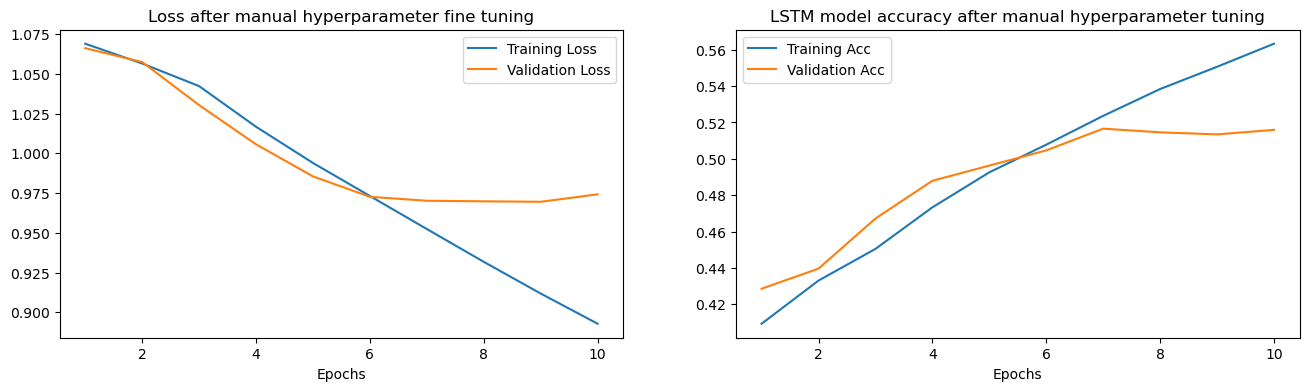

In [257]:
# Plotting the loss on the first subplot
hist_m = model_LSTM_manual_fit.history
fig = plt.figure(figsize = (16, 4))
ax = fig.add_subplot(1, 2, 1)
plt.plot(range(1, num_epochs+1), hist_m['loss'], label='Training Loss')
plt.plot(range(1, num_epochs+1), hist_m['val_loss'], label='Validation Loss')
plt.legend()
ax.set_xlabel('Epochs')
ax.set_title('Loss after manual hyperparameter fine tuning');

# Plotting the accuracy on the second subplot
ax = fig.add_subplot(1, 2, 2)
plt.plot(range(1, num_epochs+1), hist_m['accuracy'], label='Training Acc')
plt.plot(range(1, num_epochs+1), hist_m['val_accuracy'], label='Validation Acc')
plt.legend()
ax.set_xlabel('Epochs')
ax.set_title('LSTM model accuracy after manual hyperparameter tuning')
plt.show()

As we can see from above, we seem to be in a decent spot, and training it more would like cause more overfitting.

In [258]:
# Evaluating the model against X_test and Y_test
model_LSTM_manual.evaluate(X_test, Y_test)

149/149 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.5108 - loss: 0.9892


[0.9792104363441467, 0.5246315598487854]

On a more positive note, evaluating this model with the test dataset shows us that the forecasting does perform much better than before (previous accuracy was ~0.40 with the test dataset). This is likely the case because the training data we used was much closer to the test data, and we were able to take advantage of that time proximity to make our predictions.

With that being said, we should also be careful of these results BECAUSE our test data is comparatively much more limited (though 4,750 results is still likely enough data points).

### Plotting a confusion matrix for the test predictions

In [259]:
# Getting Y_test_pred for the model
Y_test_pred = model_LSTM_manual.predict(X_test)
Y_test_pred = np.argmax(Y_test_pred, axis = 1)

# Getting the confusion matrix using Y_test and Y_test_pred
cf = confusion_matrix(
    Y_test,
    Y_test_pred
)

print('Generating the confusion matrix using confusion_matrix from '
  'sklearn.metrics:')
cf

149/149 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step
Generating the confusion matrix using confusion_matrix from sklearn.metrics:


array([[910, 400, 329],
       [392, 716, 379],
       [347, 411, 866]])

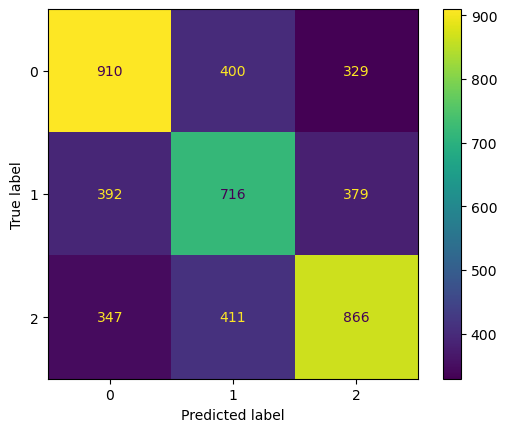

In [260]:
# Plotting the confusion matrix for the model (getting vertical xticks)
disp = ConfusionMatrixDisplay.from_predictions(
    y_true=Y_test,
    y_pred=Y_test_pred,
    labels=None
)

In [261]:
# Getting the precision and recall scores:
precision = sklearn.metrics.precision_score(Y_test, Y_test_pred, average=None)
recall = sklearn.metrics.recall_score(Y_test, Y_test_pred, average=None)

print("Determining precision for each class:")
print(precision, '\n')
print("Determining recall for each class:")
print(recall, '\n')
print("With 2 being positive prediction, 0 being negative, and 1 being neutral.")

Determining precision for each class:
[0.55184961 0.46889325 0.5501906 ] 

Determining recall for each class:
[0.5552166  0.48150639 0.53325123] 

With 2 being positive prediction, 0 being negative, and 1 being neutral.


What matters for us is precision (TP / (TP + FP)), as we care about how "right" we are when we predict a certain class. For example, if we predict a stock to close higher than its open for a particular day, we want to know how "precise" that measurement is. In our case, the precision for the long-entry case (positive - 2) and the short-entry case (negative - 0) were both around 55%, which is actually better than with the previous data. Furthermore, we still need to keep in mind that because we're considering 3 classes, 55% might not be so bad.

Again, we might be able to exclude the "neutral" class of 1 when considering our precision, as this neutral case just means that the stock didn't move very much. For a more concrete example, imagine that the Open price of a stock is 100 USD. Our definition of a "neutral" class is that the stock price remains between 0.5% and -0.5% of its opening price, which in our case would mean between 99.5 USD and 100.5 USD. Thus, if we went long and **bought** 10 shares of this stock (for a total cost of $1000), our maximum gain or loss would be ±5 USD (disregarding any fees or commissions that need to be paid).

Based on the matrix above, if our model predicted that we should've entered long, we would've remained neutral about 24% of the time (379 / (329 + 379 + 866)). However, that also means that 55% of the time (866 / (329 + 379 + 866)) we would've made money, and 21% of the time (329 / (329 + 379 + 866)) we would've lost money. In essence, here's what our numbers would look like if we exclude the neutral case:
 - Precision for class 0: **72%** (910 / (347 + 910))
 - Precision for class 2: **72%** (866 / (329 + 866))

Again, while this does not guarantee profitability, it does provide even more evidence that the model is performing better than before, especially with this corrected dataset.

## LSTM Classification (all stocks, longer series, smaller test and validation data sizes)

### Generating X continuous series sequences, Y continuous labels, and splitting data into train and test sets

In [262]:
# Creating sequences for LSTM model
seq_length = 35
group_col = 'Ticker'
target_col = 'Close_Open_Diff_Ternary'
drop_cols = ['Date_col', 'Close_Open_Diff_Perc']

X_data_smaller, Y_data_smaller = create_sequences_grouped(data_smaller, seq_length, group_col, target_col, drop_cols)

In [263]:
# Confirming shapes
print('Shape of X_data_smaller:', X_data_smaller.shape)
print('Shape of Y_data_smaller:', Y_data_smaller.shape, '\n')

# Confirming that we should have the correct number of sequences in X_data_smaller
unique_tickers = data_smaller['Ticker'].nunique()
unique_dates = data_smaller['Date_col'].nunique()
expected_num_sequences = unique_tickers * (unique_dates - seq_length + 1)

print('Number of unique tickers in data_smaller:', unique_tickers)
print('Number of unique dates in data_smaller:', unique_dates)
print('Chosen sequence length:', seq_length)
print('Number of sequences assuming the above seq_length:', unique_dates - seq_length + 1)
print('(We need to add 1 to the end to account for either the beginning or the end. For example, if we had 12 observations with a window')
print('of 5, we would need 12 - 5 + 1 = 8 sequences, the first one being having indices from [0:5], and the last from [7:12].)\n')
print('Total number of data sequences expected:', expected_num_sequences)
print('Total number of data sequences achieved:', X_data_smaller.shape[0])

Shape of X_data_smaller: (437475, 35, 32)
Shape of Y_data_smaller: (437475,) 

Number of unique tickers in data_smaller: 475
Number of unique dates in data_smaller: 955
Chosen sequence length: 35
Number of sequences assuming the above seq_length: 921
(We need to add 1 to the end to account for either the beginning or the end. For example, if we had 12 observations with a window
of 5, we would need 12 - 5 + 1 = 8 sequences, the first one being having indices from [0:5], and the last from [7:12].)

Total number of data sequences expected: 437475
Total number of data sequences achieved: 437475


In [264]:
# Getting the number of sequences per ticker (same calculation as above, but now defined in a variable)
num_sequences_per_ticker = unique_dates - seq_length + 1

# Splitting the data into train and test sets
num_train_seq_int = int(0.99 * num_sequences_per_ticker)  # Need int split to separate correct number of sequences for train and test data
train_size = num_train_seq_int * unique_tickers  # Another way to think about it: regardless of the num_train_seq_int value, we need to go
# ^up by the number of tickers (e.g., 400) at an integer amount each time
X_train = X_data_smaller[:train_size]
Y_train = Y_data_smaller[:train_size]
X_test = X_data_smaller[train_size:]
Y_test = Y_data_smaller[train_size:]

# Confirming shapes
print('Shape of X_train:', X_train.shape)
print('Shape of Y_train:', Y_train.shape)
print('Shape of X_test:', X_test.shape)
print('Shape of Y_test:', Y_test.shape, '\n')

# Confirming number of dates
print('Number of dates in X_train:', num_train_seq_int)
print('Number of dates in X_test:', num_sequences_per_ticker - num_train_seq_int)

Shape of X_train: (432725, 35, 32)
Shape of Y_train: (432725,)
Shape of X_test: (4750, 35, 32)
Shape of Y_test: (4750,) 

Number of dates in X_train: 911
Number of dates in X_test: 10


### Building and compiling LSTM model

In [265]:
# Defining a function to create and compile tf model (256 LSTM units with longer series)
def build_LSTM_model_long(seq_length,
                     num_features,
                     n_classes,
                     hidden_layer_sizes=[],
                     learning_rate=0.01,
                     activation='relu',
                     optimizer='SGD',
                     metric='accuracy'):

    # Resetting tf for consistent results
    tf.keras.backend.clear_session()
    np.random.seed(0)
    tf.random.set_seed(0)
    
    # Building a model using tf Sequential
    model = tf.keras.Sequential()

    # Input layer
    model.add(tf.keras.Input(shape=(seq_length, num_features), name='Input'))
    
    # LSTM layer 1, dropout layer 1, LSTM layer 2, dropout layer 2
    model.add(LSTM(units=256, return_sequences=True, name='LSTM_1'))
    model.add(Dropout(0.2, name='Dropout_1'))
    model.add(LSTM(units=256, name='LSTM_2'))
    model.add(Dropout(0.2, name='Dropout_2'))

    # Output layer
    model.add(tf.keras.layers.Dense(
      units = n_classes,
      activation = 'softmax',
      name = 'Output'
    ))

    # Hidden layers
    for idx, hidden_layer_size in enumerate(hidden_layer_sizes):
      model.add(tf.keras.layers.Dense(
          units = hidden_layer_size,
          activation = 'relu',
          name = 'Hidden'+str(idx)
      ))
    
    # Setting optimizer and specific learning rate
    optimizer_class = getattr(tf.keras.optimizers, optimizer)
    optimizer_true = optimizer_class(learning_rate=learning_rate)
    
    # Compiling the model
    model.compile(
      optimizer = optimizer_true,
      loss = tf.keras.losses.SparseCategoricalCrossentropy(),
      metrics = [metric]
    )
    
    return model

### Hyperparameter-tuned LSTM model

In [266]:
tf.random.set_seed(1234)
np.random.seed(1234)

# Setting hyperparameters
seq_length = X_train.shape[1]
num_features = X_train.shape[2]
n_classes = 3
hidden_layer_sizes = []
learning_rate = 0.001
activation = 'relu'
optimizer = 'Adam'
metric = 'accuracy'
num_epochs = 10
batch_size = 1024

# Building and compiling the model
model_LSTM_long = build_LSTM_model_long(seq_length=seq_length,
                                      num_features=num_features,
                                      n_classes=n_classes,
                                      hidden_layer_sizes=hidden_layer_sizes,
                                      learning_rate=learning_rate,
                                      activation=activation,
                                      optimizer=optimizer,
                                      metric=metric)
print(model_LSTM_long.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ LSTM_1 (LSTM)                   │ (None, 35, 256)        │       295,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_1 (Dropout)             │ (None, 35, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ LSTM_2 (LSTM)                   │ (None, 256)            │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 822,019 (3.14 MB)

 Trainable params: 822,019 (3.14 MB)

 Non-trainable params: 0 (0.00 B)

None


In [267]:
# Training the model using the training dataset
model_LSTM_long_fit = model_LSTM_long.fit(
    x = X_train,
    y = Y_train,
    validation_split = 0.01,  # Validation split also 0.01 just like the test split
    epochs = num_epochs,
    batch_size = batch_size,
    verbose = 1
)

Epoch 1/10
419/419 ━━━━━━━━━━━━━━━━━━━━ 266s 631ms/step - accuracy: 0.3833 - loss: 1.0878 - val_accuracy: 0.4115 - val_loss: 1.0748
Epoch 2/10
419/419 ━━━━━━━━━━━━━━━━━━━━ 263s 628ms/step - accuracy: 0.4142 - loss: 1.0665 - val_accuracy: 0.4335 - val_loss: 1.0632
Epoch 3/10
419/419 ━━━━━━━━━━━━━━━━━━━━ 261s 622ms/step - accuracy: 0.4278 - loss: 1.0595 - val_accuracy: 0.4422 - val_loss: 1.0567
Epoch 4/10
419/419 ━━━━━━━━━━━━━━━━━━━━ 260s 621ms/step - accuracy: 0.4382 - loss: 1.0530 - val_accuracy: 0.4600 - val_loss: 1.0448
Epoch 5/10
419/419 ━━━━━━━━━━━━━━━━━━━━ 263s 627ms/step - accuracy: 0.4547 - loss: 1.0394 - val_accuracy: 0.4783 - val_loss: 1.0209
Epoch 6/10
419/419 ━━━━━━━━━━━━━━━━━━━━ 260s 620ms/step - accuracy: 0.4765 - loss: 1.0145 - val_accuracy: 0.4947 - val_loss: 0.9979
Epoch 7/10
419/419 ━━━━━━━━━━━━━━━━━━━━ 257s 612ms/step - accuracy: 0.4976 - loss: 0.9884 - val_accuracy: 0.5025 - val_loss: 0.9790
Epoch 8/10
419/419 ━━━━━━━━━━━━━━━━━━━━ 259s 618ms/step - accuracy: 0.5145 -

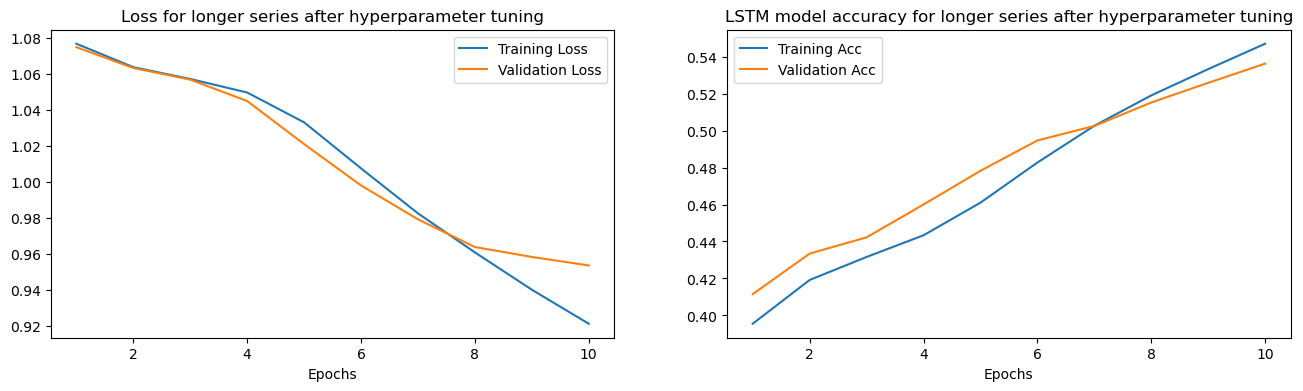

In [268]:
# Plotting the loss on the first subplot
hist_l = model_LSTM_long_fit.history
fig = plt.figure(figsize = (16, 4))
ax = fig.add_subplot(1, 2, 1)
plt.plot(range(1, num_epochs+1), hist_l['loss'], label='Training Loss')
plt.plot(range(1, num_epochs+1), hist_l['val_loss'], label='Validation Loss')
plt.legend()
ax.set_xlabel('Epochs')
ax.set_title('Loss for longer series after hyperparameter tuning');

# Plotting the accuracy on the second subplot
ax = fig.add_subplot(1, 2, 2)
plt.plot(range(1, num_epochs+1), hist_l['accuracy'], label='Training Acc')
plt.plot(range(1, num_epochs+1), hist_l['val_accuracy'], label='Validation Acc')
plt.legend()
ax.set_xlabel('Epochs')
ax.set_title('LSTM model accuracy for longer series after hyperparameter tuning')
plt.show()

As it takes over 4 minutes to run each epoch, and the validation loss seems to be plateauing now, it probably doesn't make sense to waste more compute and continue running. However, even with this run, we see that the validation accuracy almost reaches 54%, which is an improvement over the previous model with a smaller window of 14 days.

In [269]:
print("Final training accuracy:", hist_l['accuracy'][-1])
print("Final validation accuracy:", hist_l['val_accuracy'][-1])

Final training accuracy: 0.547053337097168
Final validation accuracy: 0.5362753868103027


In [270]:
# Evaluating the model against X_test and Y_test
model_LSTM_long.evaluate(X_test, Y_test)

149/149 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - accuracy: 0.5257 - loss: 0.9574


[0.9456563591957092, 0.5265263319015503]

Once again, evaluating this longer-sequence model with the test dataset shows us that the forecasting does perform much better than before (previous accuracy was ~0.40 with the longer sequences). Again, this is likely the case because the training data we used was much closer to the test data, and we were able to take advantage of that time proximity to make our predictions.

Also again, we should be careful of these results because our test data is comparatively much more limited (though 4,750 results is still likely enough data points). But it's good to see that the training, validation, and test accuracies were even better than the previous model with shorter sequences.

### Plotting a confusion matrix for the test predictions

In [271]:
# Getting Y_test_pred for the model
Y_test_pred = model_LSTM_long.predict(X_test)
Y_test_pred = np.argmax(Y_test_pred, axis = 1)

# Getting the confusion matrix using Y_test and Y_test_pred
cf = confusion_matrix(
    Y_test,
    Y_test_pred
)

print('Generating the confusion matrix using confusion_matrix from '
  'sklearn.metrics:')
cf

149/149 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step
Generating the confusion matrix using confusion_matrix from sklearn.metrics:


array([[922, 400, 330],
       [420, 695, 372],
       [325, 402, 884]])

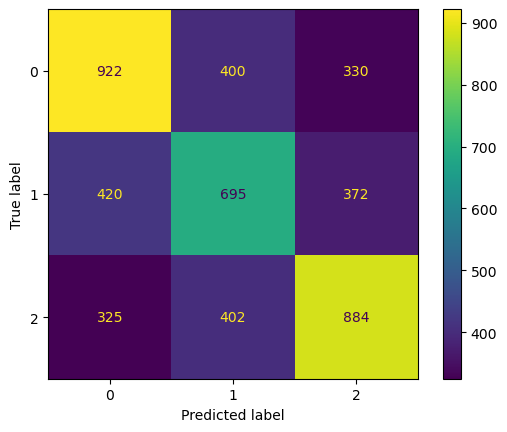

In [272]:
# Plotting the confusion matrix for the model (getting vertical xticks)
disp = ConfusionMatrixDisplay.from_predictions(
    y_true=Y_test,
    y_pred=Y_test_pred,
    labels=None
)

In [273]:
# Getting the precision and recall scores:
precision = sklearn.metrics.precision_score(Y_test, Y_test_pred, average=None)
recall = sklearn.metrics.recall_score(Y_test, Y_test_pred, average=None)

print("Determining precision for each class:")
print(precision, '\n')
print("Determining recall for each class:")
print(recall, '\n')
print("With 2 being positive prediction, 0 being negative, and 1 being neutral.")

Determining precision for each class:
[0.55308938 0.46426186 0.55737705] 

Determining recall for each class:
[0.55811138 0.46738399 0.5487275 ] 

With 2 being positive prediction, 0 being negative, and 1 being neutral.


Once again, what matters for us is precision (TP / (TP + FP)), as we care about how "right" we are when we predict a certain class. For example, if we predict a stock to close higher than its open for a particular day, we want to know how "precise" that measurement is. Similar to the case above, when considering precision of only classes 2 and 0, we get the following precision values:
 - Precision for class 0: **74%** (922 / (922 + 325))
 - Precision for class 2: **73%** (884 / (330 + 884))

This is interesting - while our precision was better than our previous model, our precision for class 2 was actually slightly worse than this same model when using the old dataset. It's a little bit unclear why this is happening, but perhaps we're introducing too much noise into the data. Perhaps with PCA our model will be able to extract the most salient features better, but then we'll have to worry about interpretation.

### (Optional) One more test with hyperparameter tuning (256 batch size instead of 1024, and 15 epochs instead of 10)

In [274]:
tf.random.set_seed(1234)
np.random.seed(1234)

# Setting hyperparameters
seq_length = X_train.shape[1]
num_features = X_train.shape[2]
n_classes = 3
hidden_layer_sizes = []
learning_rate = 0.001
activation = 'relu'
optimizer = 'Adam'
metric = 'accuracy'
num_epochs = 15
batch_size = 256

# Building and compiling the model
model_LSTM_long = build_LSTM_model_long(seq_length=seq_length,
                                      num_features=num_features,
                                      n_classes=n_classes,
                                      hidden_layer_sizes=hidden_layer_sizes,
                                      learning_rate=learning_rate,
                                      activation=activation,
                                      optimizer=optimizer,
                                      metric=metric)
print(model_LSTM_long.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ LSTM_1 (LSTM)                   │ (None, 35, 256)        │       295,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_1 (Dropout)             │ (None, 35, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ LSTM_2 (LSTM)                   │ (None, 256)            │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 822,019 (3.14 MB)

 Trainable params: 822,019 (3.14 MB)

 Non-trainable params: 0 (0.00 B)

None


In [275]:
# Training the model using the training dataset
model_LSTM_long_fit = model_LSTM_long.fit(
    x = X_train,
    y = Y_train,
    validation_split = 0.01,  # Validation split also 0.01 just like the test split
    epochs = num_epochs,
    batch_size = batch_size,
    verbose = 1
)

Epoch 1/15
1674/1674 ━━━━━━━━━━━━━━━━━━━━ 359s 214ms/step - accuracy: 0.3945 - loss: 1.0790 - val_accuracy: 0.4235 - val_loss: 1.0647
Epoch 2/15
1674/1674 ━━━━━━━━━━━━━━━━━━━━ 348s 208ms/step - accuracy: 0.4255 - loss: 1.0602 - val_accuracy: 0.4348 - val_loss: 1.0566
Epoch 3/15
1674/1674 ━━━━━━━━━━━━━━━━━━━━ 346s 207ms/step - accuracy: 0.4435 - loss: 1.0492 - val_accuracy: 0.4737 - val_loss: 1.0258
Epoch 4/15
1674/1674 ━━━━━━━━━━━━━━━━━━━━ 359s 215ms/step - accuracy: 0.4712 - loss: 1.0196 - val_accuracy: 0.4924 - val_loss: 0.9869
Epoch 5/15
1674/1674 ━━━━━━━━━━━━━━━━━━━━ 366s 219ms/step - accuracy: 0.4990 - loss: 0.9852 - val_accuracy: 0.5083 - val_loss: 0.9653
Epoch 6/15
1674/1674 ━━━━━━━━━━━━━━━━━━━━ 365s 218ms/step - accuracy: 0.5193 - loss: 0.9587 - val_accuracy: 0.5247 - val_loss: 0.9525
Epoch 7/15
1674/1674 ━━━━━━━━━━━━━━━━━━━━ 363s 217ms/step - accuracy: 0.5357 - loss: 0.9350 - val_accuracy: 0.5261 - val_loss: 0.9410
Epoch 8/15
1674/1674 ━━━━━━━━━━━━━━━━━━━━ 346s 207ms/step - ac

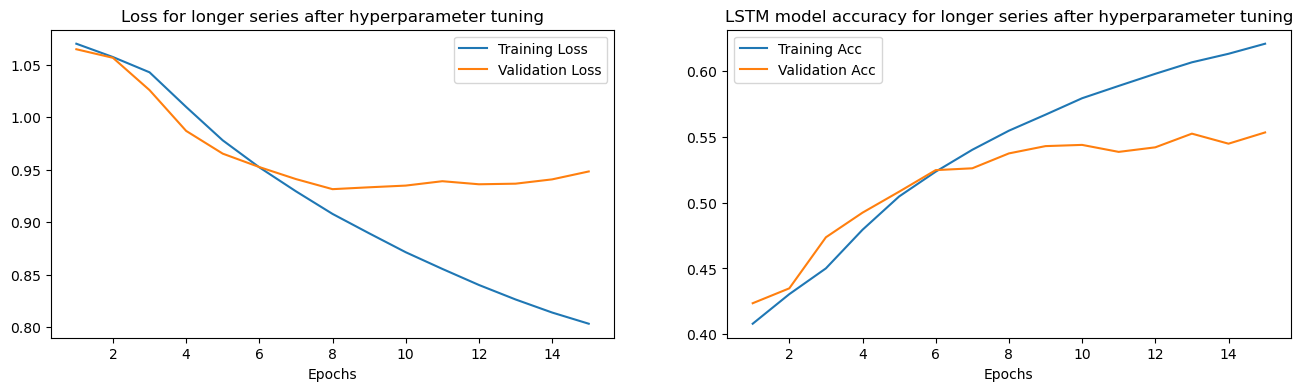

In [276]:
# Plotting the loss on the first subplot
hist_l = model_LSTM_long_fit.history
fig = plt.figure(figsize = (16, 4))
ax = fig.add_subplot(1, 2, 1)
plt.plot(range(1, num_epochs+1), hist_l['loss'], label='Training Loss')
plt.plot(range(1, num_epochs+1), hist_l['val_loss'], label='Validation Loss')
plt.legend()
ax.set_xlabel('Epochs')
ax.set_title('Loss for longer series after hyperparameter tuning');

# Plotting the accuracy on the second subplot
ax = fig.add_subplot(1, 2, 2)
plt.plot(range(1, num_epochs+1), hist_l['accuracy'], label='Training Acc')
plt.plot(range(1, num_epochs+1), hist_l['val_accuracy'], label='Validation Acc')
plt.legend()
ax.set_xlabel('Epochs')
ax.set_title('LSTM model accuracy for longer series after hyperparameter tuning')
plt.show()

It took over 6 minutes to run each epoch, and overall the validation loss hasn't improved that much (and it started overfitting). Thus, it probably makes sense to just keep the previous model and not worry too much about it. But... let's see the test results anyway:

In [279]:
# Evaluating the model against X_test and Y_test
model_LSTM_long.evaluate(X_test, Y_test)

149/149 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.5349 - loss: 0.9725


[0.9687816500663757, 0.5383157730102539]

### (Optional) Confusion matrix for the test predictions (>75% precision for classes 0 and 2)

In [280]:
# Getting Y_test_pred for the model
Y_test_pred = model_LSTM_long.predict(X_test)
Y_test_pred = np.argmax(Y_test_pred, axis = 1)

# Getting the confusion matrix using Y_test and Y_test_pred
cf = confusion_matrix(
    Y_test,
    Y_test_pred
)

print('Generating the confusion matrix using confusion_matrix from '
  'sklearn.metrics:')
cf

149/149 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step
Generating the confusion matrix using confusion_matrix from sklearn.metrics:


array([[960, 382, 310],
       [388, 652, 447],
       [299, 367, 945]])

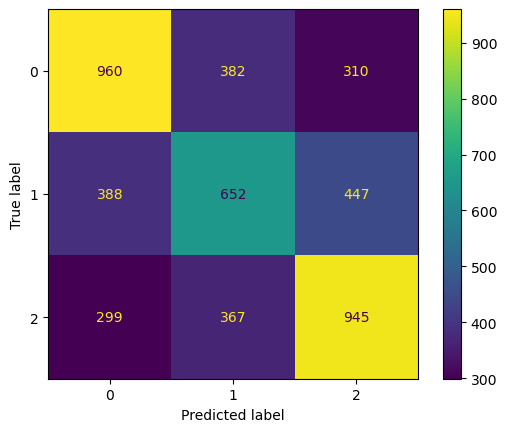

In [281]:
# Plotting the confusion matrix for the model (getting vertical xticks)
disp = ConfusionMatrixDisplay.from_predictions(
    y_true=Y_test,
    y_pred=Y_test_pred,
    labels=None
)

In [282]:
# Getting the precision and recall scores:
precision = sklearn.metrics.precision_score(Y_test, Y_test_pred, average=None)
recall = sklearn.metrics.recall_score(Y_test, Y_test_pred, average=None)

print("Determining precision for each class:")
print(precision, '\n')
print("Determining recall for each class:")
print(recall, '\n')
print("With 2 being positive prediction, 0 being negative, and 1 being neutral.")

Determining precision for each class:
[0.58287796 0.46538187 0.55522914] 

Determining recall for each class:
[0.5811138  0.43846671 0.58659218] 

With 2 being positive prediction, 0 being negative, and 1 being neutral.


While this model does perform better, with a better overall test accuracy as well, it's still likely just due to some extra training. Nevertheless, if we test the precision for classes 0 and 2 while disregarding the neutral class, we get the following accuracies:
 - Precision for class 0: **76%** (960 / (960 + 299))
 - Precision for class 2: **75%** (945 / (310 + 945))

And we confirm again that the precisions broke the 75% mark, which is indeed quite good. One thought is that a simpler LSTM model might perform just as well (since it's not as bloated and might not be prone to as much overfitting, so we shall try that next.

## LSTM Classification (all stocks, longer series, smaller test and validation data sizes, simpler model)
This simpler model uses one fewer LSTM layer and dropout layer

### Generating X continuous series sequences, Y continuous labels, and splitting data into train and test sets

In [144]:
# Creating sequences for LSTM model
seq_length = 35
group_col = 'Ticker'
target_col = 'Close_Open_Diff_Ternary'
drop_cols = ['Date_col', 'Close_Open_Diff_Perc']

X_data_smaller, Y_data_smaller = create_sequences_grouped(data_smaller, seq_length, group_col, target_col, drop_cols)

In [145]:
# Confirming shapes
print('Shape of X_data_smaller:', X_data_smaller.shape)
print('Shape of Y_data_smaller:', Y_data_smaller.shape, '\n')

# Confirming that we should have the correct number of sequences in X_data_smaller
unique_tickers = data_smaller['Ticker'].nunique()
unique_dates = data_smaller['Date_col'].nunique()
expected_num_sequences = unique_tickers * (unique_dates - seq_length + 1)

print('Number of unique tickers in data_smaller:', unique_tickers)
print('Number of unique dates in data_smaller:', unique_dates)
print('Chosen sequence length:', seq_length)
print('Number of sequences assuming the above seq_length:', unique_dates - seq_length + 1, '\n')
print('Total number of data sequences expected:', expected_num_sequences)
print('Total number of data sequences achieved:', X_data_smaller.shape[0])

Shape of X_data_smaller: (437475, 35, 32)
Shape of Y_data_smaller: (437475,) 

Number of unique tickers in data_smaller: 475
Number of unique dates in data_smaller: 955
Chosen sequence length: 35
Number of sequences assuming the above seq_length: 921 

Total number of data sequences expected: 437475
Total number of data sequences achieved: 437475


In [146]:
# Getting the number of sequences per ticker
num_sequences_per_ticker = unique_dates - seq_length + 1

# Splitting the data into train and test sets
num_train_seq_int = int(0.99 * num_sequences_per_ticker)
train_size = num_train_seq_int * unique_tickers
X_train = X_data_smaller[:train_size]
Y_train = Y_data_smaller[:train_size]
X_test = X_data_smaller[train_size:]
Y_test = Y_data_smaller[train_size:]

# Confirming shapes
print('Shape of X_train:', X_train.shape)
print('Shape of Y_train:', Y_train.shape)
print('Shape of X_test:', X_test.shape)
print('Shape of Y_test:', Y_test.shape, '\n')

# Confirming number of dates
print('Number of dates in X_train:', num_train_seq_int)
print('Number of dates in X_test:', num_sequences_per_ticker - num_train_seq_int)

Shape of X_train: (432725, 35, 32)
Shape of Y_train: (432725,)
Shape of X_test: (4750, 35, 32)
Shape of Y_test: (4750,) 

Number of dates in X_train: 911
Number of dates in X_test: 10


### Building and compiling simpler LSTM model
This is where the primary change lies - we will remove one LSTM layer and check performance

In [293]:
# Defining a function to create and compile tf model only one LSTM layer (also 256 units and dropout of 0.3)
def build_LSTM_model_simple(seq_length,
                     num_features,
                     n_classes,
                     learning_rate=0.01,
                     activation='relu',
                     optimizer='SGD',
                     metric='accuracy'):

    # Resetting tf for consistent results
    tf.keras.backend.clear_session()
    np.random.seed(0)
    tf.random.set_seed(0)
    
    # Building a model using tf Sequential
    model = tf.keras.Sequential()

    # Input layer
    model.add(tf.keras.Input(shape=(seq_length, num_features), name='Input'))
    
    # LSTM layer
    model.add(LSTM(units=256, name='LSTM'))

    # Dropout layer
    model.add(Dropout(0.3, name='Dropout'))

    # Output layer
    model.add(tf.keras.layers.Dense(
      units = n_classes,
      activation = 'softmax',
      name = 'Output'
    ))
    
    # Setting optimizer and specific learning rate
    optimizer_class = getattr(tf.keras.optimizers, optimizer)
    optimizer_true = optimizer_class(learning_rate=learning_rate)
    
    # Compiling the model
    model.compile(
      optimizer = optimizer_true,
      loss = tf.keras.losses.SparseCategoricalCrossentropy(),
      metrics = [metric]
    )
    
    return model

### Hyperparameter-tuned LSTM model

In [291]:
tf.random.set_seed(1234)
np.random.seed(1234)

# Setting hyperparameters
seq_length = X_train.shape[1]
num_features = X_train.shape[2]
n_classes = 3
learning_rate = 0.001
activation = 'relu'
optimizer = 'Adam'
metric = 'accuracy'
num_epochs = 10
batch_size = 256  # Updated to 256

# Building and compiling the model
model_LSTM_simple = build_LSTM_model_simple(seq_length=seq_length,
                                      num_features=num_features,
                                      n_classes=n_classes,
                                      learning_rate=learning_rate,
                                      activation=activation,
                                      optimizer=optimizer,
                                      metric=metric)
print(model_LSTM_simple.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ LSTM (LSTM)                     │ (None, 256)            │       295,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 296,707 (1.13 MB)

 Trainable params: 296,707 (1.13 MB)

 Non-trainable params: 0 (0.00 B)

None


In [292]:
# Training the model using the training dataset
model_LSTM_simple_fit = model_LSTM_simple.fit(
    x = X_train,
    y = Y_train,
    validation_split = 0.01,
    epochs = num_epochs,
    batch_size = batch_size,
    verbose = 1
)

Epoch 1/10
1674/1674 ━━━━━━━━━━━━━━━━━━━━ 156s 93ms/step - accuracy: 0.3959 - loss: 1.0782 - val_accuracy: 0.4235 - val_loss: 1.0687
Epoch 2/10
1674/1674 ━━━━━━━━━━━━━━━━━━━━ 154s 92ms/step - accuracy: 0.4219 - loss: 1.0627 - val_accuracy: 0.4258 - val_loss: 1.0629
Epoch 3/10
1674/1674 ━━━━━━━━━━━━━━━━━━━━ 155s 93ms/step - accuracy: 0.4318 - loss: 1.0575 - val_accuracy: 0.4429 - val_loss: 1.0530
Epoch 4/10
1674/1674 ━━━━━━━━━━━━━━━━━━━━ 154s 92ms/step - accuracy: 0.4495 - loss: 1.0434 - val_accuracy: 0.4637 - val_loss: 1.0286
Epoch 5/10
1674/1674 ━━━━━━━━━━━━━━━━━━━━ 147s 88ms/step - accuracy: 0.4735 - loss: 1.0179 - val_accuracy: 0.4767 - val_loss: 1.0086
Epoch 6/10
1674/1674 ━━━━━━━━━━━━━━━━━━━━ 153s 91ms/step - accuracy: 0.4918 - loss: 0.9936 - val_accuracy: 0.5002 - val_loss: 0.9860
Epoch 7/10
1674/1674 ━━━━━━━━━━━━━━━━━━━━ 148s 88ms/step - accuracy: 0.5077 - loss: 0.9726 - val_accuracy: 0.5030 - val_loss: 0.9775
Epoch 8/10
1674/1674 ━━━━━━━━━━━━━━━━━━━━ 148s 88ms/step - accuracy: 

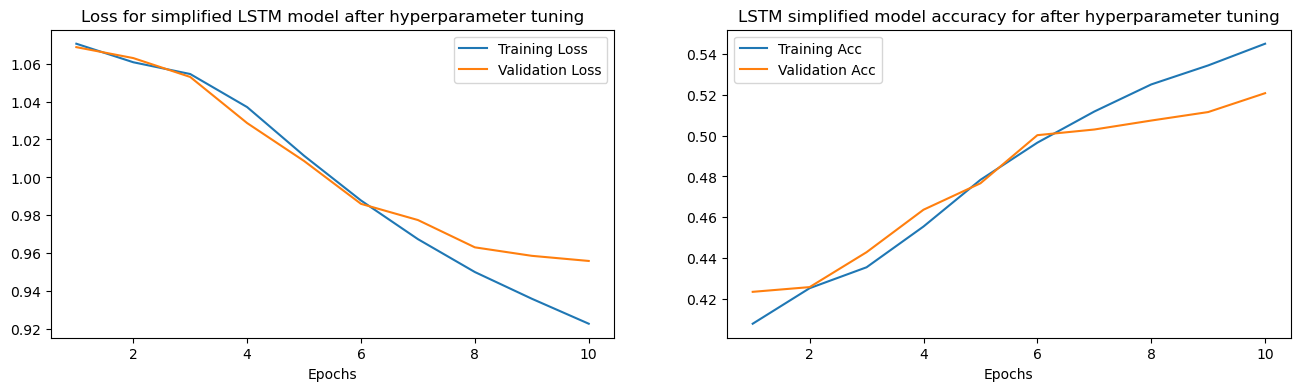

In [294]:
# Plotting the loss on the first subplot
hist_s = model_LSTM_simple_fit.history
fig = plt.figure(figsize = (16, 4))
ax = fig.add_subplot(1, 2, 1)
plt.plot(range(1, num_epochs+1), hist_s['loss'], label='Training Loss')
plt.plot(range(1, num_epochs+1), hist_s['val_loss'], label='Validation Loss')
plt.legend()
ax.set_xlabel('Epochs')
ax.set_title('Loss for simplified LSTM model after hyperparameter tuning');

# Plotting the accuracy on the second subplot
ax = fig.add_subplot(1, 2, 2)
plt.plot(range(1, num_epochs+1), hist_s['accuracy'], label='Training Acc')
plt.plot(range(1, num_epochs+1), hist_s['val_accuracy'], label='Validation Acc')
plt.legend()
ax.set_xlabel('Epochs')
ax.set_title('LSTM simplified model accuracy for after hyperparameter tuning')
plt.show()

It took about 2.5 minutes to run each epoch, though this time, the validation loss could potentially get a little better. It might be worth it to run it for a little longer, perhaps lowering the learning rate and running the model for 10 more epochs to see where it ends up. Unfortunately, we seem to have to define the learning rate beforehand, so it might be impossible to change it now. Still, if we do want to in the future using a learning rate scheduler, we can use the link below to get the code:
https://medium.com/thedeephub/learning-rate-and-its-strategies-in-neural-network-training-270a91ea0e5c#:~:text=The%20learning%20rate%20is%20reduced,that%20slows%20down%20over%20time.

In [295]:
#tensorflow
# lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(initial_learning_rate=0.01, decay_steps=10000, decay_rate=0.5, staircase=True)
# optimizer = tf.keras.optimizers.SGD(learning_rate=lr_schedule)

For now though, let's just run the model for 3 more epochs and see where we end up

In [296]:
num_epochs_cont = 3
# Training the model using the training dataset
model_LSTM_simple_fit = model_LSTM_simple.fit(
    x = X_train,
    y = Y_train,
    validation_split = 0.01,
    epochs = num_epochs_cont,
    batch_size = batch_size,
    verbose = 1
)

Epoch 1/3
1674/1674 ━━━━━━━━━━━━━━━━━━━━ 154s 92ms/step - accuracy: 0.5499 - loss: 0.9148 - val_accuracy: 0.5210 - val_loss: 0.9620
Epoch 2/3
1674/1674 ━━━━━━━━━━━━━━━━━━━━ 154s 92ms/step - accuracy: 0.5575 - loss: 0.9032 - val_accuracy: 0.5330 - val_loss: 0.9626
Epoch 3/3
1674/1674 ━━━━━━━━━━━━━━━━━━━━ 161s 96ms/step - accuracy: 0.5625 - loss: 0.8943 - val_accuracy: 0.5291 - val_loss: 0.9626


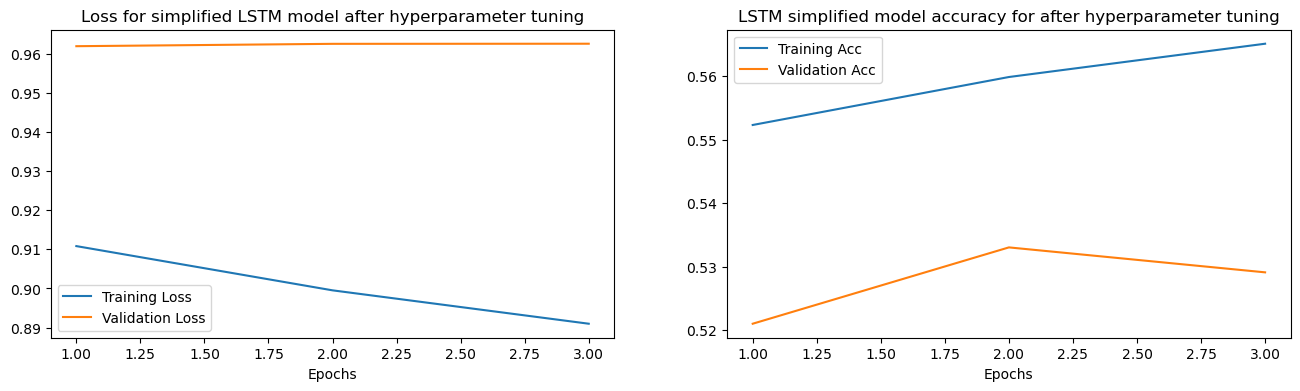

In [297]:
# Plotting the loss on the first subplot
hist_s = model_LSTM_simple_fit.history
fig = plt.figure(figsize = (16, 4))
ax = fig.add_subplot(1, 2, 1)
plt.plot(range(1, num_epochs_cont+1), hist_s['loss'], label='Training Loss')
plt.plot(range(1, num_epochs_cont+1), hist_s['val_loss'], label='Validation Loss')
plt.legend()
ax.set_xlabel('Epochs')
ax.set_title('Loss for simplified LSTM model after hyperparameter tuning');

# Plotting the accuracy on the second subplot
ax = fig.add_subplot(1, 2, 2)
plt.plot(range(1, num_epochs_cont+1), hist_s['accuracy'], label='Training Acc')
plt.plot(range(1, num_epochs_cont+1), hist_s['val_accuracy'], label='Validation Acc')
plt.legend()
ax.set_xlabel('Epochs')
ax.set_title('LSTM simplified model accuracy for after hyperparameter tuning')
plt.show()

There seems to be very little improvement, so perhaps this is as far as we can go with this simplified model

In [298]:
print("Final training accuracy:", hist_s['accuracy'][-1])
print("Final validation accuracy:", hist_s['val_accuracy'][-1])

Final training accuracy: 0.5650996565818787
Final validation accuracy: 0.5291127562522888


In [299]:
# Evaluating the model against X_test and Y_test
model_LSTM_simple.evaluate(X_test, Y_test)

149/149 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.5113 - loss: 0.9708


[0.9647052884101868, 0.520421028137207]

The test accuracy is at least somewhat comparable to the accuracies we achieved previously. More importantly, while it may be 1 or 2 percent lower, it runs faster, and it uses fewer compute resources. Thus, it might be prudent to continue with this simplified model for now.

Either way, we can plot the confusion matrix to see how precise our test predictions are.

### Plotting a confusion matrix for the test predictions

In [300]:
# Getting Y_test_pred for the model
Y_test_pred = model_LSTM_simple.predict(X_test)
Y_test_pred = np.argmax(Y_test_pred, axis = 1)

# Getting the confusion matrix using Y_test and Y_test_pred
cf = confusion_matrix(
    Y_test,
    Y_test_pred
)

print('Generating the confusion matrix using confusion_matrix from '
  'sklearn.metrics:')
cf

149/149 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step
Generating the confusion matrix using confusion_matrix from sklearn.metrics:


array([[884, 425, 343],
       [382, 670, 435],
       [301, 392, 918]])

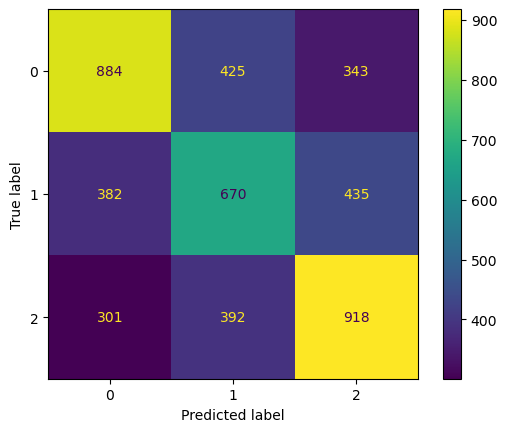

In [301]:
# Plotting the confusion matrix for the model (getting vertical xticks)
disp = ConfusionMatrixDisplay.from_predictions(
    y_true=Y_test,
    y_pred=Y_test_pred,
    labels=None
)

In [302]:
# Getting the precision and recall scores:
precision = sklearn.metrics.precision_score(Y_test, Y_test_pred, average=None)
recall = sklearn.metrics.recall_score(Y_test, Y_test_pred, average=None)

print("Determining precision for each class:")
print(precision, '\n')
print("Determining recall for each class:")
print(recall, '\n')
print("With 2 being positive prediction, 0 being negative, and 1 being neutral.")

Determining precision for each class:
[0.56413529 0.45057162 0.54127358] 

Determining recall for each class:
[0.53510896 0.45057162 0.5698324 ] 

With 2 being positive prediction, 0 being negative, and 1 being neutral.


Once again, what matters for us is precision (TP / (TP + FP)), as we care about how "right" we are when we predict a certain class. For example, if we predict a stock to close higher than its open for a particular day, we want to know how "precise" that measurement is. Similar to all the previous cases, when considering the precision of only classes 2 and 0, we get the following precision values:
 - Precision for class 0: **75%** (884 / (884 + 301))
 - Precision for class 2: **73%** (918 / (343 + 918))

Again, the precision for the 2 relevant classes is at roughly the level we saw before. We'll try a few more things to simplify the model even further, but we want to make sure we don't simplify too much to the point where we see a significant drop in the test accuracy.

## LSTM Classification (all stocks, longer series, smaller test and validation data sizes, simpler model, 128 LSTM units)
This is a continuation of the previous experiment to try simplifying the model, so we'll exclude the parts that are the same as before

### Building and compiling simpler LSTM model
Once again, this is where the primary change lies - we will change the 256 LSTM units back to 128 units to see if it can still produce good results

In [147]:
# Defining a function to create and compile tf model only one LSTM layer (but with 128 units)
def build_LSTM_model_simple_128(seq_length,
                     num_features,
                     n_classes,
                     learning_rate=0.01,
                     activation='relu',
                     optimizer='SGD',
                     metric='accuracy'):

    # Resetting tf for consistent results
    tf.keras.backend.clear_session()
    np.random.seed(0)
    tf.random.set_seed(0)
    
    # Building a model using tf Sequential
    model = tf.keras.Sequential()

    # Input layer
    model.add(tf.keras.Input(shape=(seq_length, num_features), name='Input'))
    
    # LSTM layer
    model.add(LSTM(units=128, name='LSTM'))

    # Dropout layer
    model.add(Dropout(0.3, name='Dropout'))

    # Output layer
    model.add(tf.keras.layers.Dense(
      units = n_classes,
      activation = 'softmax',
      name = 'Output'
    ))
    
    # Setting optimizer and specific learning rate
    optimizer_class = getattr(tf.keras.optimizers, optimizer)
    optimizer_true = optimizer_class(learning_rate=learning_rate)
    
    # Compiling the model
    model.compile(
      optimizer = optimizer_true,
      loss = tf.keras.losses.SparseCategoricalCrossentropy(),
      metrics = [metric]
    )
    
    return model

### Hyperparameter-tuned LSTM model

In [167]:
tf.random.set_seed(1234)
np.random.seed(1234)

# Setting hyperparameters
seq_length = X_train.shape[1]
num_features = X_train.shape[2]
n_classes = 3
learning_rate = 0.001
activation = 'relu'
optimizer = 'Adam'
metric = 'accuracy'
num_epochs = 10
batch_size = 256

# Building and compiling the model
model_LSTM_simple_128 = build_LSTM_model_simple_128(seq_length=seq_length,
                                      num_features=num_features,
                                      n_classes=n_classes,
                                      learning_rate=learning_rate,
                                      activation=activation,
                                      optimizer=optimizer,
                                      metric=metric)
print(model_LSTM_simple_128.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ LSTM (LSTM)                     │ (None, 128)            │        82,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 82,819 (323.51 KB)

 Trainable params: 82,819 (323.51 KB)

 Non-trainable params: 0 (0.00 B)

None


In [168]:
# Training the model using the training dataset
model_LSTM_simple_128_fit = model_LSTM_simple_128.fit(
    x = X_train,
    y = Y_train,
    validation_split = 0.01,
    epochs = num_epochs,
    batch_size = batch_size,
    verbose = 1
)

Epoch 1/10
1674/1674 ━━━━━━━━━━━━━━━━━━━━ 109s 65ms/step - accuracy: 0.3942 - loss: 1.0790 - val_accuracy: 0.4214 - val_loss: 1.0709
Epoch 2/10
1674/1674 ━━━━━━━━━━━━━━━━━━━━ 105s 63ms/step - accuracy: 0.4201 - loss: 1.0638 - val_accuracy: 0.4274 - val_loss: 1.0642
Epoch 3/10
1674/1674 ━━━━━━━━━━━━━━━━━━━━ 107s 64ms/step - accuracy: 0.4284 - loss: 1.0587 - val_accuracy: 0.4321 - val_loss: 1.0594
Epoch 4/10
1674/1674 ━━━━━━━━━━━━━━━━━━━━ 109s 65ms/step - accuracy: 0.4392 - loss: 1.0526 - val_accuracy: 0.4482 - val_loss: 1.0483
Epoch 5/10
1674/1674 ━━━━━━━━━━━━━━━━━━━━ 107s 64ms/step - accuracy: 0.4535 - loss: 1.0408 - val_accuracy: 0.4642 - val_loss: 1.0317
Epoch 6/10
1674/1674 ━━━━━━━━━━━━━━━━━━━━ 110s 66ms/step - accuracy: 0.4667 - loss: 1.0247 - val_accuracy: 0.4686 - val_loss: 1.0195
Epoch 7/10
1674/1674 ━━━━━━━━━━━━━━━━━━━━ 112s 67ms/step - accuracy: 0.4788 - loss: 1.0103 - val_accuracy: 0.4787 - val_loss: 1.0090
Epoch 8/10
1674/1674 ━━━━━━━━━━━━━━━━━━━━ 106s 64ms/step - accuracy: 

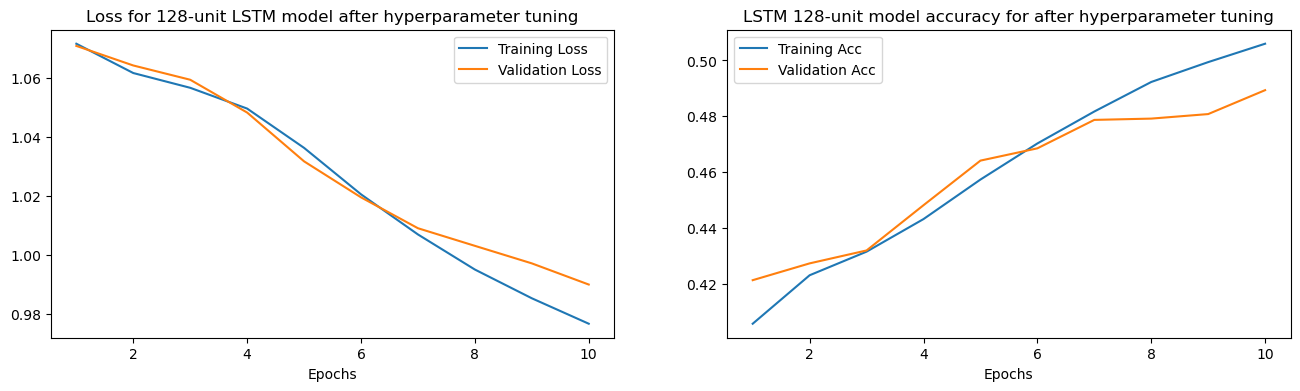

In [169]:
# Plotting the loss on the first subplot
hist_s_128 = model_LSTM_simple_128_fit.history
fig = plt.figure(figsize = (16, 4))
ax = fig.add_subplot(1, 2, 1)
plt.plot(range(1, num_epochs+1), hist_s_128['loss'], label='Training Loss')
plt.plot(range(1, num_epochs+1), hist_s_128['val_loss'], label='Validation Loss')
plt.legend()
ax.set_xlabel('Epochs')
ax.set_title('Loss for 128-unit LSTM model after hyperparameter tuning');

# Plotting the accuracy on the second subplot
ax = fig.add_subplot(1, 2, 2)
plt.plot(range(1, num_epochs+1), hist_s_128['accuracy'], label='Training Acc')
plt.plot(range(1, num_epochs+1), hist_s_128['val_accuracy'], label='Validation Acc')
plt.legend()
ax.set_xlabel('Epochs')
ax.set_title('LSTM 128-unit model accuracy for after hyperparameter tuning')
plt.show()

Similar to before, it does appear that we can train this model for a bit longer (perhaps 5 more epochs). Let's try that and see where this model ends up.

In [170]:
num_epochs_cont = 5
# Training the model using the training dataset
model_LSTM_simple_128_fit = model_LSTM_simple_128.fit(
    x = X_train,
    y = Y_train,
    validation_split = 0.01,
    epochs = num_epochs_cont,
    batch_size = batch_size,
    verbose = 1
)

Epoch 1/5
1674/1674 ━━━━━━━━━━━━━━━━━━━━ 104s 62ms/step - accuracy: 0.5096 - loss: 0.9716 - val_accuracy: 0.4908 - val_loss: 0.9855
Epoch 2/5
1674/1674 ━━━━━━━━━━━━━━━━━━━━ 106s 63ms/step - accuracy: 0.5139 - loss: 0.9651 - val_accuracy: 0.4908 - val_loss: 0.9816
Epoch 3/5
1674/1674 ━━━━━━━━━━━━━━━━━━━━ 105s 63ms/step - accuracy: 0.5195 - loss: 0.9589 - val_accuracy: 0.4984 - val_loss: 0.9775
Epoch 4/5
1674/1674 ━━━━━━━━━━━━━━━━━━━━ 108s 65ms/step - accuracy: 0.5228 - loss: 0.9537 - val_accuracy: 0.4949 - val_loss: 0.9759
Epoch 5/5
1674/1674 ━━━━━━━━━━━━━━━━━━━━ 102s 61ms/step - accuracy: 0.5268 - loss: 0.9487 - val_accuracy: 0.4972 - val_loss: 0.9722


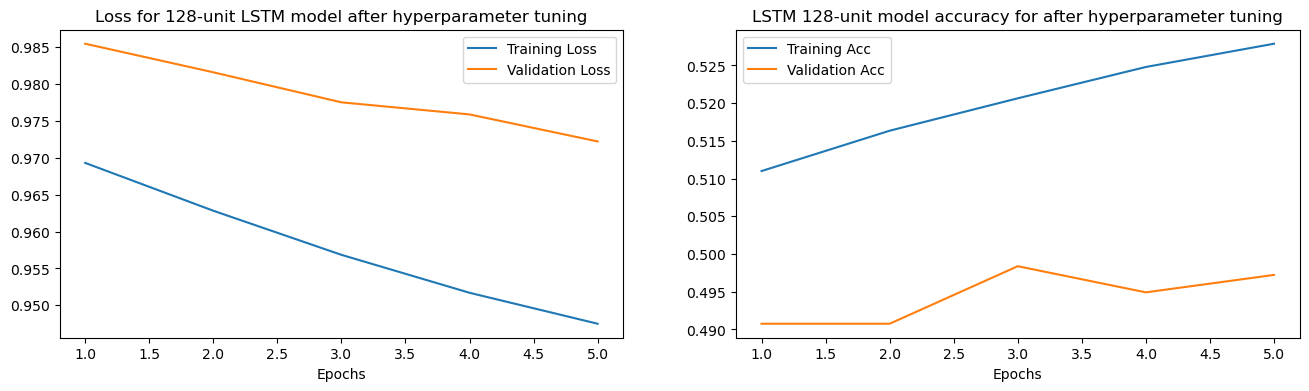

In [171]:
# Plotting the loss on the first subplot
hist_s_128 = model_LSTM_simple_128_fit.history
fig = plt.figure(figsize = (16, 4))
ax = fig.add_subplot(1, 2, 1)
plt.plot(range(1, num_epochs_cont+1), hist_s_128['loss'], label='Training Loss')
plt.plot(range(1, num_epochs_cont+1), hist_s_128['val_loss'], label='Validation Loss')
plt.legend()
ax.set_xlabel('Epochs')
ax.set_title('Loss for 128-unit LSTM model after hyperparameter tuning');

# Plotting the accuracy on the second subplot
ax = fig.add_subplot(1, 2, 2)
plt.plot(range(1, num_epochs_cont+1), hist_s_128['accuracy'], label='Training Acc')
plt.plot(range(1, num_epochs_cont+1), hist_s_128['val_accuracy'], label='Validation Acc')
plt.legend()
ax.set_xlabel('Epochs')
ax.set_title('LSTM 128-unit model accuracy for after hyperparameter tuning')
plt.show()

In [172]:
print("Final training accuracy:", hist_s_128['accuracy'][-1])
print("Final validation accuracy:", hist_s_128['val_accuracy'][-1])

Final training accuracy: 0.527877151966095
Final validation accuracy: 0.49722737073898315


It definitely did not take as long to run each epoch - a bit less than 2 minutes this time - though the validation accuracy did take a hit. We'll check the test accuracy to confirm how well our model generalizes, but this model might not capture the complexities of the data as well as previous ones.

In [173]:
# Evaluating the model against X_test and Y_test
model_LSTM_simple_128.evaluate(X_test, Y_test)

149/149 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4959 - loss: 0.9857


[0.9797451496124268, 0.4997894763946533]

The test accuracy is indeed somewhat worse than before (by ~2%). Therefore, it's questionable whether we should move forward with this simpler model.

Either way, we will once again plot a confusion matrix to see how well our test predictions did.

### Plotting a confusion matrix for the test predictions

In [174]:
# Getting Y_test_pred for the model
Y_test_pred = model_LSTM_simple_128.predict(X_test)
Y_test_pred = np.argmax(Y_test_pred, axis = 1)

# Getting the confusion matrix using Y_test and Y_test_pred
cf = confusion_matrix(
    Y_test,
    Y_test_pred
)

print('Generating the confusion matrix using confusion_matrix from '
  'sklearn.metrics:')
cf

149/149 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
Generating the confusion matrix using confusion_matrix from sklearn.metrics:


array([[832, 435, 385],
       [350, 708, 429],
       [356, 421, 834]])

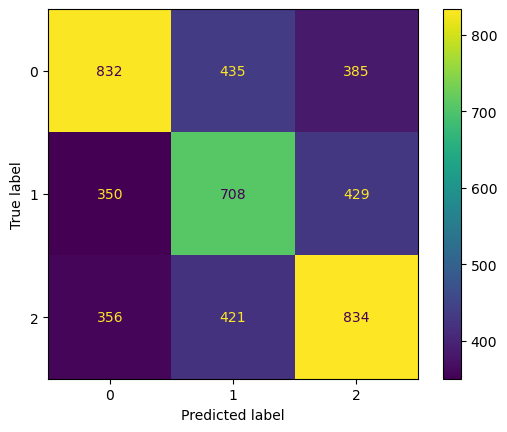

In [175]:
# Plotting the confusion matrix for the model (getting vertical xticks)
disp = ConfusionMatrixDisplay.from_predictions(
    y_true=Y_test,
    y_pred=Y_test_pred,
    labels=None
)

In [176]:
# Getting the precision and recall scores:
precision = sklearn.metrics.precision_score(Y_test, Y_test_pred, average=None)
recall = sklearn.metrics.recall_score(Y_test, Y_test_pred, average=None)

print("Determining precision for each class:")
print(precision, '\n')
print("Determining recall for each class:")
print(recall, '\n')
print("With 2 being positive prediction, 0 being negative, and 1 being neutral.")

Determining precision for each class:
[0.54096229 0.45268542 0.50606796] 

Determining recall for each class:
[0.50363196 0.47612643 0.51769088] 

With 2 being positive prediction, 0 being negative, and 1 being neutral.


As before, what matters for us is precision (TP / (TP + FP)), as we care about how "right" we are when we predict a certain class. Similar to all the previous cases, when considering the precision of only classes 2 and 0, we get the following precision values:

 - Precision for class 0: 70% (832 / (832 + 356))
 - Precision for class 2: 68% (834 / (385 + 834))

As expected, the precision for the 2 relevant classes is quite a bit worse than before. Therefore, we will probably not use this simplified version of the model. In terms of the opposite direction - i.e., tuning this model more - it's likely more worthwhile to move on to bigger changes so we can get more significant improvements.

## Conclusions for True Sequence LSTM Models with 99/1 Train/Test Split
Overall, this is the first experiment where we can definitively say we got decent results. Notably, our most complex model - with all stocks, longer series, and smaller test and validation data sizes - performed the best, and it achieved an accuracy of almost 54%. As explained in the confusion matrix sections, that figure is not as important to us as the accuracies for classes 0 and 2, and limiting our analyses to just those classes reveals a precision of over 75%. We will perform more in-depth evaluations in the last set of evaluation notebooks, and we will likely choose this most complex model as it achieves the best accuracies for us.

The simpler models also worked quite well, trading some accuracy for faster training time. We will continue experimenting with this in the next set of models (and the PCA models as well), but the primary purpose of the simpler models was to help expedite our testing and analyses for other techniques.